# **Benchmarking Generative Models for Conformational Sampling Against Biomolecular Dynamics Simulations**

---

### **MSc Project (AI for Drug Discovery)**

## Ioannis Arzinos

##### supervised by Dr. Wojciech Kopec

---

### Research Question

This study aims to compare three deep learning methods and evaluate their predicted ensembles along the two defining axes of biological relevance: structural similarity to experimentally resolved structures and dynamic behaviour. Using IL-2 as the model system, a library of experimentally resolved structures was curated for evaluating the biological relevance of the predicted ensembles against each state ensemble as the upper bound. After analysing their recovered quality, structural similarity and conformational diversity, a sampling strategy was employed to seed AI-generated structures for running short-timescale MD simulations. By using experimentally resolved structures as initial positions and running MD simulations of crystallographic structures as state representatives, the structural evolution of seeded structures is benchmarked in physical space against the structural similarity and conformational space explored by crystallographic structure simulations as the upper bound. The objective of this study is therefore twofold: to show the extent to which these techniques provide biologically relevant structures in terms of their coordinates, and to what extent these seeds reproduce this biological relevance in physical space compared to crystallographic IL-2 structures under short-timescale MD simulations.

# Appendix 2 — Molecular Dynamics Trajectory Analysis

This appendix carries out the dynamic half of the study's biological-relevance framework (Research Question, above): whether the static, pre-simulation selection criteria used to pick AI-generated seeds (fidelity, transition-state, diversity, discordance) predict how those seeds actually behave once released into explicit-solvent molecular dynamics.

**How to use this notebook.** Every section below is self-contained and runs top to bottom without edits, provided the data roots defined in Section 0 resolve on your machine. Re-running the whole notebook regenerates every table and figure from the raw `.xtc`/`.gro` trajectory files fresh — nothing here is hardcoded from a previous run. Sections are numbered to match the structure below; each analysis section carries its own short **Interpretation** and **Reproducibility** markdown cell immediately after its figures, so results and their reading sit next to each other rather than being deferred to a separate discussion.

1. [Introduction and Scope](#1.-Introduction-and-Scope)
2. [System Discovery](#2.-System-Discovery)
3. [Selection-Philosophy Framework](#3.-Selection-Philosophy-Framework)
4. [Structural Similarity](#4.-Structural-Similarity)
   - 4.1 Cα RMSD (whole-protein)
   - 4.2 Cα RMSD (binding site)
5. [RMSF Analysis (Supplementary)](#5.-RMSF-Analysis-(Supplementary))
6. [PCA Convex-Hull Overlap](#6.-PCA-Convex-Hull-Overlap)
7. [Landmark-Specific State Recovery](#7.-Landmark-Specific-State-Recovery)

## 0. Setup — Environment, Constants and Helper Functions

Everything in this section is infrastructure: imports, file-path roots, and the analysis functions every later section calls. Nothing here produces a result on its own — skip straight to [Section 1](#1.-Introduction-and-Scope) if you only want the narrative.

Residue lists, thresholds and PCA/RMSD/pocket-volume code are ported **unchanged** from the static ensemble-analysis notebook (`IL2_Conformational_Analysis.ipynb`) so that both notebooks stay numerically identical wherever they overlap. Section 0.2 recomputes the reference-derived constants (pocket-lining residue set, pooled χ1 angles, open/closed threshold) fresh from the source PDBs rather than hardcoding them, with an assertion against the published values as a safety net against silent drift in the reference library.

In [1]:
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patheffects as pe
from matplotlib.colors import to_rgba
from matplotlib.patches import Polygon as MplHullPatch
import mdtraj as md
from scipy.spatial import ConvexHull, cKDTree
from sklearn.decomposition import PCA

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 20)

# --- Shared colour palette (colour-blind-safe; reused throughout the notebook) -------
COLOR_REF = "#4d4d4d"
COLOR_MSA = "#0072B2"   # MSA Subsampling
COLOR_AFS2 = "#009E73"  # AFsample2
COLOR_BIO = "#D55E00"   # BioEmu
MODEL_COLORS = {"MSA Subsampling": COLOR_MSA, "AFsample2": COLOR_AFS2, "BioEmu": COLOR_BIO,
                 "Reference": COLOR_REF}
BIOEMU_CENTROID_COLORS = {
    "ai_seeds_BioEmu_01_centroid_01": "#722F37",  # wine
    "ai_seeds_BioEmu_02_centroid_02": "#D62728",  # red
    "ai_seeds_BioEmu_03_centroid_03": "#FF8C00",  # orange
}
_OUTLINE = [pe.withStroke(linewidth=1.4, foreground="black")]

mpl.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "font.size": 10,
})

STATES = ["apo", "holo", "ligand"]
STATE_LABELS = {"apo": "Apo (unbound)", "holo": "Holo (IL-2Ra-bound)",
                "ligand": "Ligand-bound (cryptic pocket)"}
STATE_DISPLAY = {"apo": "Apo", "holo": "Holo", "ligand": "Ligand"}


def display_table(df, caption=None, precision=2):
    """Publication-styled render of a results DataFrame: rounded floats, hidden index,
    a light header rule and an optional caption. Purely cosmetic -- never mutates `df`."""
    sty = df.style.format(precision=precision, na_rep="—").hide(axis="index")
    sty = sty.set_table_styles([
        {"selector": "th", "props": [("text-align", "center"), ("border-bottom", "1.5px solid #333"),
                                       ("padding", "4px 10px")]},
        {"selector": "td", "props": [("text-align", "center"), ("padding", "3px 10px")]},
    ])
    if caption:
        sty = sty.set_caption(caption).set_table_styles(
            [{"selector": "caption", "props": [("caption-side", "top"), ("font-weight", "600"),
                                                 ("padding-bottom", "6px")]}], overwrite=False)
    return sty


# --- Absolute project roots (two separate top-level project trees on disk; kept absolute
#     rather than relative since they are not meant to move together) -------------------
# --- Relative paths, portable across machines (rewritten from the original absolute macOS
#     paths this notebook was developed with, for inclusion in the reproducibility repo) -----
REFERENCE_ROOT = "../02_ensemble_analysis/data/raw"          # same reference library Appendix 1 uses
STATE_DIRS = {s: f"{REFERENCE_ROOT}/{s}" for s in STATES}
MD_SEEDS_ROOT = "./data/md_seeds"                              # optional; see SEED_SS_PATH below
PRODUCTION_ROOT = "../03_md_simulations/production_data"       # replicate 1, shared with Workflow 3
REPLICAS_ROOT = "../03_md_simulations/replicates_data"          # replicates 2-3
FIGURES_DIR = "./figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

IL2_SEQUENCE = (
    "APTSSSTKKTQLQLEHLLLDLQMILNGINNYKNPKLTRMLTFKFYMPKKATELKHLQCLE"
    "EELKPLEEVLNLAQSKNFHLRPRDLISNINVIVLELKGSETTFMCEYADETATIVEFLNR"
    "WITFCQSIISTLT"
)
THREE_TO_ONE = {
    "ALA": "A", "ARG": "R", "ASN": "N", "ASP": "D", "CYS": "C", "GLN": "Q",
    "GLU": "E", "GLY": "G", "HIS": "H", "ILE": "I", "LEU": "L", "LYS": "K",
    "MET": "M", "PHE": "F", "PRO": "P", "SER": "S", "THR": "T", "TRP": "W",
    "TYR": "Y", "VAL": "V", "MSE": "M",
}
# Cryptic-pocket gating residues (chi1 = N-CA-CB-CG) -- identical to the static notebook.
GATING_RESIDUES = {42: "PHE", 45: "TYR", 62: "GLU"}
NON_LIGAND_HET = {"HOH", "ZN", "NA", "CL", "MG", "CA", "K", "MN", "CU",
                  "SO4", "GOL", "EDO", "PO4", "ACT", "TRS", "PEG"}
QC_OVERRIDE_INCLUDE = {"2ERJ"}  # reviewed mutation-bias override, see static notebook Section 1


def load_pdb_angstrom(path):
    t = md.load(path)
    t.xyz = t.xyz * 10.0
    return t


def find_il2_chains(traj, min_identity=0.9):
    hits = []
    for chain in traj.topology.chains:
        resids, seq = [], []
        for res in chain.residues:
            one = THREE_TO_ONE.get(res.name)
            if one is None:
                continue
            resids.append(res.resSeq)
            seq.append(one)
        seq = "".join(seq)
        if len(seq) < 50:
            continue
        n_match = n_compare = 0
        for rid, aa in zip(resids, seq):
            idx = rid - 1
            if 0 <= idx < len(IL2_SEQUENCE):
                n_compare += 1
                if IL2_SEQUENCE[idx] == aa:
                    n_match += 1
        if n_compare >= 50 and (n_match / n_compare) >= min_identity:
            hits.append(chain.index)
    return hits


def ca_single_chain_trajs(pdb_path):
    traj = load_pdb_angstrom(pdb_path)
    pdb_id = os.path.basename(pdb_path).replace(".pdb", "")
    out = []
    for cidx in find_il2_chains(traj):
        chain = traj.topology.chain(cidx)
        ca_idx = [a.index for a in chain.atoms if a.name == "CA"]
        out.append((f"{pdb_id}:chain{cidx}", traj.atom_slice(ca_idx)))
    return out


def full_atom_single_chain_trajs(pdb_path):
    traj = load_pdb_angstrom(pdb_path)
    pdb_id = os.path.basename(pdb_path).replace(".pdb", "")
    out = []
    for cidx in find_il2_chains(traj):
        chain = traj.topology.chain(cidx)
        idx = [a.index for a in chain.atoms]
        out.append((f"{pdb_id}:chain{cidx}", traj.atom_slice(idx)))
    return out


def common_resSeqs(trajs):
    sets = [set(a.residue.resSeq for a in t.topology.atoms) for t in trajs]
    return sorted(set.intersection(*sets))


def slice_to_resSeqs(traj, resSeqs):
    keep = [a.index for a in traj.topology.atoms if a.residue.resSeq in resSeqs]
    return traj.atom_slice(keep)


def stack_trajs(trajs):
    xyz = np.concatenate([t.xyz for t in trajs], axis=0)
    return md.Trajectory(xyz=xyz, topology=trajs[0].topology)


def load_reference_state(state):
    paths = sorted(glob.glob(f"{STATE_DIRS[state]}/*.pdb"))
    labels, trajs = [], []
    for p in paths:
        for label, t in ca_single_chain_trajs(p):
            pdb_id = os.path.basename(p).replace(".pdb", "")
            labels.append(f"{pdb_id}:{label.split(':')[-1]}")
            trajs.append(t)
    return labels, trajs


def qc_filter_reference(state, labels, trajs):
    """Wild-type-Cys125-only inclusion criterion with the reviewed 2ERJ override, identical
    logic to the static notebook's Section 1 QC step (3INK excluded, 2ERJ retained)."""
    keep_labels, keep_trajs = [], []
    for label, t in zip(labels, trajs):
        pdb_id = label.split(":")[0]
        res_by_id = {a.residue.resSeq: a.residue.name for a in t.topology.atoms}
        wild_type_c125 = res_by_id.get(125, "n/a") == "CYS"
        if wild_type_c125 or pdb_id in QC_OVERRIDE_INCLUDE:
            keep_labels.append(label)
            keep_trajs.append(t)
    return keep_labels, keep_trajs


def fit_state_pca(ref_trajs, n_components=2):
    resid_list = common_resSeqs(ref_trajs)
    sliced = [slice_to_resSeqs(t, set(resid_list)) for t in ref_trajs]
    ref_traj = stack_trajs(sliced)
    ref_traj.superpose(ref_traj, frame=0)
    mean_traj = md.Trajectory(xyz=ref_traj.xyz.mean(axis=0, keepdims=True), topology=ref_traj.topology)
    ref_traj.superpose(mean_traj, frame=0)
    if ref_traj.n_frames < 3:
        return dict(resid_list=resid_list, ref_traj=ref_traj, mean_target=mean_traj,
                    pca=None, mean_=None, ref_scores=None)
    X = ref_traj.xyz.reshape(ref_traj.n_frames, -1)
    mean_ = X.mean(axis=0)
    pca = PCA(n_components=n_components)
    ref_scores = pca.fit_transform(X - mean_)
    return dict(resid_list=resid_list, ref_traj=ref_traj, mean_target=mean_traj,
                pca=pca, mean_=mean_, ref_scores=ref_scores)


def project_onto_pca(traj, basis):
    sliced = slice_to_resSeqs(traj, set(basis["resid_list"]))
    sliced = sliced[:]
    sliced.superpose(basis["mean_target"], frame=0)
    if basis["pca"] is None:
        return None, sliced
    X = sliced.xyz.reshape(sliced.n_frames, -1)
    scores = basis["pca"].transform(X - basis["mean_"])
    return scores, sliced


def find_pocket_lining_residues(pdb_path, cutoff_A=4.5):
    traj = load_pdb_angstrom(pdb_path)
    top = traj.topology
    il2_chains = set(find_il2_chains(traj))
    prot_idx = [a.index for a in top.atoms
                if a.residue.chain.index in il2_chains and a.element.symbol != "H"]
    lig_residues = [r for r in top.residues
                    if not r.is_protein and not r.is_water and r.name not in NON_LIGAND_HET]
    if not lig_residues or not prot_idx:
        return set()
    tree = cKDTree(traj.xyz[0][prot_idx])
    contacts = set()
    for r in lig_residues:
        lig_idx = [a.index for a in r.atoms if a.element.symbol != "H"]
        for hits in tree.query_ball_point(traj.xyz[0][lig_idx], r=cutoff_A):
            for j in hits:
                contacts.add(top.atom(prot_idx[j]).residue.resSeq)
    return contacts


def chi1_for_gating_residues(traj, residues=GATING_RESIDUES):
    chi1_idx, chi1_vals = md.compute_chi1(traj)
    out = {}
    for i, quad in enumerate(chi1_idx):
        res = traj.topology.atom(quad[0]).residue
        if res.resSeq in residues and res.name == residues[res.resSeq]:
            out[res.resSeq] = np.degrees(chi1_vals[:, i])
    return out


def angular_diff(a, b):
    d = np.abs(a - b) % 360.0
    return np.where(d <= 180.0, d, 360.0 - d)


def pocket_hull_volume_series_A3(traj, resSeqs):
    """Per-frame pocket-lining side-chain (heavy-atom, no backbone) convex-hull volume,
    Angstrom^3 -- identical construction to the static notebook."""
    idx = [a.index for a in traj.topology.atoms
           if a.residue.resSeq in resSeqs and a.name not in ("N", "CA", "C", "O")
           and a.element.symbol != "H"]
    return np.array([ConvexHull(traj.xyz[i][idx]).volume for i in range(traj.n_frames)])

### 0.1 Recompute reference-derived constants fresh from source

Rather than hardcode the static notebook's printed numbers (13-residue pocket set, pooled χ1 angles, 1483.9 Å³ threshold), these are recomputed here from the same reference PDBs using the functions above — guaranteed bit-identical to the static notebook as long as the source reference library hasn't changed, with an assertion against the published values as a safety net.

In [2]:
# --- 1. Pooled, QC-filtered reference chains per state (CA-only) --------------------
ref_labels, ref_trajs = {}, {}
for state in STATES:
    labels, trajs = load_reference_state(state)
    labels, trajs = qc_filter_reference(state, labels, trajs)
    ref_labels[state], ref_trajs[state] = labels, trajs
    print(f"{STATE_LABELS[state]}: {len(trajs)} pooled reference chains -> {labels}")

# --- 2. Pocket-lining residue set: intersection across all 4 ligand-bound reference PDBs
lining_per_pdb = {}
for p in sorted(glob.glob(f"{STATE_DIRS['ligand']}/*.pdb")):
    pdb_id = os.path.basename(p).replace(".pdb", "")
    lining_per_pdb[pdb_id] = find_pocket_lining_residues(p)
POCKET_LINING_RESIDUES = sorted(set.intersection(*lining_per_pdb.values()))
print(f"\nPOCKET_LINING_RESIDUES (n={len(POCKET_LINING_RESIDUES)}): {POCKET_LINING_RESIDUES}")
assert POCKET_LINING_RESIDUES == [35, 38, 39, 41, 42, 43, 44, 45, 62, 65, 69, 72, 73], (
    "Pocket-lining residue set no longer matches the static notebook's reported n=13 set -- "
    "the reference PDB library under REFERENCE_ROOT has changed; re-validate downstream results.")

# --- 3. Pooled ligand-bound reference chi1 (Phe42/Tyr45/Glu62) ----------------------
ligand_chi1_rows = []
for p in sorted(glob.glob(f"{STATE_DIRS['ligand']}/*.pdb")):
    pdb_id = os.path.basename(p).replace(".pdb", "")
    for label, t in full_atom_single_chain_trajs(p):
        chi1 = {r: v[0] for r, v in chi1_for_gating_residues(t).items()}
        ligand_chi1_rows.append(dict(pdb_id=pdb_id, **{f"res{r}": v for r, v in chi1.items()}))
ligand_chi1_df = pd.DataFrame(ligand_chi1_rows)
REF_CHI1 = {r: float(ligand_chi1_df[f"res{r}"].mean()) for r in GATING_RESIDUES}
print(f"\nPooled ligand-bound reference chi1: { {k: round(v, 1) for k, v in REF_CHI1.items()} }")

# --- 4. Pocket open/closed threshold: pooled (apo+holo) closed mean + 2 SD ----------
pocket_rows = []
EXCLUDED_PDB_IDS = {"3INK"}  # engineered C125A mutant, excluded from the reference pool (Section 0 QC)
for state in STATES:
    for p in sorted(glob.glob(f"{STATE_DIRS[state]}/*.pdb")):
        pdb_id = os.path.basename(p).replace(".pdb", "")
        if pdb_id in EXCLUDED_PDB_IDS:
            continue
        for label, t in full_atom_single_chain_trajs(p):
            resolved = set(a.residue.resSeq for a in t.topology.atoms)
            if not set(POCKET_LINING_RESIDUES).issubset(resolved):
                continue
            vol = pocket_hull_volume_series_A3(t, POCKET_LINING_RESIDUES)[0]
            pocket_rows.append(dict(state=state, chain=label, hull_volume_A3=vol))
pocket_df = pd.DataFrame(pocket_rows)
closed_vol = pocket_df.loc[pocket_df.state.isin(["apo", "holo"]), "hull_volume_A3"].values
POCKET_OPEN_THRESHOLD_A3 = float(closed_vol.mean() + 2 * closed_vol.std())
print(f"POCKET_OPEN_THRESHOLD_A3 = {POCKET_OPEN_THRESHOLD_A3:.1f} A^3 "
      f"(expected ~1483.9 A^3 from the static notebook)")
assert abs(POCKET_OPEN_THRESHOLD_A3 - 1483.9) < 1.0, (
    "Pocket-open threshold has drifted from the static notebook's reported 1483.9 A^3 -- "
    "the reference PDB library has changed; re-validate downstream results.")

# --- 5. Ligand-bound pocket-volume RECOVERY range: full observed min-max of the pooled
# ligand-bound reference's own hull volume (every reference structure counts as in-range
# by construction) -- used by Section 7's state-recovery classification. ------------------
ligand_vol = pocket_df.loc[pocket_df.state == "ligand", "hull_volume_A3"].values
POCKET_RECOVERY_MIN_A3 = float(ligand_vol.min())
POCKET_RECOVERY_MAX_A3 = float(ligand_vol.max())
print(f"Pocket-volume RECOVERY range (full observed range of the pooled ligand-bound "
      f"reference hull volume, n={len(ligand_vol)}): "
      f"{POCKET_RECOVERY_MIN_A3:.1f}-{POCKET_RECOVERY_MAX_A3:.1f} A^3")

# --- 6. Reference-basis PCA per state (used throughout Sections 4-7) ---------------
pca_basis = {state: fit_state_pca(ref_trajs[state]) for state in STATES}
for state in STATES:
    basis = pca_basis[state]
    if basis["pca"] is None:
        print(f"{STATE_LABELS[state]}: PCA basis SKIPPED (<3 reference chains)")
    else:
        ev_pct = basis["pca"].explained_variance_ratio_.sum() * 100
        print(f"{STATE_LABELS[state]}: PCA basis fitted, PC1+PC2 explained variance = {ev_pct:.1f}%")

Apo (unbound): 3 pooled reference chains -> ['1M47:chain0', '1M4C:chain0', '1M4C:chain1']


Holo (IL-2Ra-bound): 4 pooled reference chains -> ['1Z92:chain0', '2B5I:chain0', '2ERJ:chain3', '2ERJ:chain7']
Ligand-bound (cryptic pocket): 10 pooled reference chains -> ['1M48:chain0', '1M48:chain1', '1M49:chain0', '1M49:chain1', '1PW6:chain0', '1PW6:chain1', '1PY2:chain0', '1PY2:chain1', '1PY2:chain2', '1PY2:chain3']



POCKET_LINING_RESIDUES (n=13): [35, 38, 39, 41, 42, 43, 44, 45, 62, 65, 69, 72, 73]

Pooled ligand-bound reference chi1: {42: -159.9, 45: -76.1, 62: -74.5}


POCKET_OPEN_THRESHOLD_A3 = 1483.9 A^3 (expected ~1483.9 A^3 from the static notebook)
Pocket-volume RECOVERY range (full observed range of the pooled ligand-bound reference hull volume, n=10): 1395.3-1596.6 A^3
Apo (unbound): PCA basis fitted, PC1+PC2 explained variance = 100.0%
Holo (IL-2Ra-bound): PCA basis fitted, PC1+PC2 explained variance = 98.0%
Ligand-bound (cryptic pocket): PCA basis fitted, PC1+PC2 explained variance = 62.2%


### 0.2 Production-trajectory loading, system registry and statistics glue

`SYSTEMS` enumerates every production system this notebook knows how to look for. `state` records which reference pool a system is naturally compared against: `"apo"`/`"holo"`/`"ligand"` for the three crystal-seeded systems and the fidelity-criterion AI seeds, and **`None`** for `transition_state`, `diversity_representative`, `discordance` and the three BioEmu centroids — these were deliberately seeded *not* to sit in one basin, so this notebook does not presuppose one: RMSD-to-reference for a `state=None` system is computed against **all three** reference pools and reported as nearest-overall.

In [3]:
SYSTEMS = [
    dict(name="apo_1M47", state="apo", model="Reference", criterion="crystal_apo",
         label="1M47 (apo crystal)"),
    dict(name="receptor_1Z92", state="holo", model="Reference", criterion="crystal_holo",
         label="1Z92 (holo crystal)"),
    dict(name="open_1PY2", state="ligand", model="Reference", criterion="crystal_ligand",
         label="1PY2 (ligand-bound crystal)"),
    dict(name="ai_seeds_MSA_Subsampling_02_fidelity_ligand", state="ligand",
         model="MSA Subsampling", criterion="fidelity_ligand"),
    dict(name="ai_seeds_MSA_Subsampling_03_transition_state", state=None,
         model="MSA Subsampling", criterion="transition_state"),
    dict(name="ai_seeds_MSA_Subsampling_04_diversity_representative", state=None,
         model="MSA Subsampling", criterion="diversity_representative"),
    dict(name="ai_seeds_MSA_Subsampling_05_discordance", state=None,
         model="MSA Subsampling", criterion="discordance"),
    dict(name="ai_seeds_AFsample2_02_fidelity_ligand", state="ligand",
         model="AFsample2", criterion="fidelity_ligand"),
    dict(name="ai_seeds_AFsample2_03_transition_state", state=None,
         model="AFsample2", criterion="transition_state"),
    dict(name="ai_seeds_AFsample2_04_diversity_representative", state=None,
         model="AFsample2", criterion="diversity_representative"),
    dict(name="ai_seeds_AFsample2_05_discordance", state=None,
         model="AFsample2", criterion="discordance"),
    dict(name="ai_seeds_BioEmu_01_centroid_01", state=None,
         model="BioEmu", criterion="centroid_01"),
    dict(name="ai_seeds_BioEmu_02_centroid_02", state=None,
         model="BioEmu", criterion="centroid_02"),
    dict(name="ai_seeds_BioEmu_03_centroid_03", state=None,
         model="BioEmu", criterion="centroid_03"),
]
SYSTEM_BY_NAME = {s["name"]: s for s in SYSTEMS}

# `Replicas/` names its MSA Subsampling replicate-2/3 directories "MSA_0N_<criterion>" rather than
# the "ai_seeds_MSA_Subsampling_0N_<criterion>" convention every other system (and replicate 1,
# under PRODUCTION_ROOT) uses -- confirmed by directory listing, not a guess.
REPLICA_DIR_ALIASES = {
    "ai_seeds_MSA_Subsampling_02_fidelity_ligand": "MSA_02_fidelity_ligand",
    "ai_seeds_MSA_Subsampling_03_transition_state": "MSA_03_transition_state",
    "ai_seeds_MSA_Subsampling_04_diversity_representative": "MSA_04_diversity_representative",
    "ai_seeds_MSA_Subsampling_05_discordance": "MSA_05_discordance",
}


def system_paths(name):
    """Replica index -> dict(gro, xtc, gro_source) for whichever replicas actually exist on
    disk for this system. Replicate 1 lives under PRODUCTION_ROOT; replicates 2/3 live under
    REPLICAS_ROOT (under REPLICA_DIR_ALIASES[name] if aliased, else `name` itself) and, where they
    have no npt.gro of their own, fall back to replicate 1's npt.gro as topology."""
    out = {}
    r1_dir = f"{PRODUCTION_ROOT}/{name}"
    r1_gro, r1_xtc = f"{r1_dir}/npt.gro", f"{r1_dir}/production.xtc"
    if os.path.exists(r1_gro) and os.path.exists(r1_xtc):
        out[1] = dict(gro=r1_gro, xtc=r1_xtc, gro_source="own")
    replica_dir_name = REPLICA_DIR_ALIASES.get(name, name)
    for rep in (2, 3):
        rep_dir = f"{REPLICAS_ROOT}/{replica_dir_name}/replica_0{rep}"
        rep_xtc = f"{rep_dir}/production.xtc"
        rep_gro_own = f"{rep_dir}/npt.gro"
        if not os.path.exists(rep_xtc):
            continue
        if os.path.exists(rep_gro_own):
            out[rep] = dict(gro=rep_gro_own, xtc=rep_xtc, gro_source="own")
        elif 1 in out:
            out[rep] = dict(gro=out[1]["gro"], xtc=rep_xtc,
                             gro_source="replica_01 npt.gro (fallback -- see Section 0.2 markdown)")
    return out


def discover_all_systems():
    rows, replica_paths = [], {}
    for sysdef in SYSTEMS:
        name = sysdef["name"]
        paths = system_paths(name)
        replica_paths[name] = paths
        rows.append(dict(
            system=name, model=sysdef["model"], criterion=sysdef["criterion"],
            state=sysdef["state"] or "(all pools)",
            replicate_1="OK" if 1 in paths else "missing",
            replicate_2="OK" if 2 in paths else "missing",
            replicate_3="OK" if 3 in paths else "missing",
            n_replicates=len(paths),
            replica_2_3_topology=("own" if any(paths.get(r, {}).get("gro_source") == "own"
                                                for r in (2, 3) if r in paths)
                                   else ("fallback" if any(r in paths for r in (2, 3)) else "n/a")),
        ))
    return pd.DataFrame(rows), replica_paths


ION_RESNAMES = {"NA", "CL"}  # the only ions GROMACS genion adds here (0.15 M NaCl, per the
                              # system-preparation report) -- confirmed against every topology.
HIS_VARIANT_RESNAMES = {"HISE", "HIE", "HID", "HIP", "HSE", "HSD", "HSP"}  # GROMACS/CHARMM/AMBER
                              # protonation-state histidine naming (His16/55/79 here) -- every
                              # AI-seeded system uses one of these; only the 3 crystal-seeded
                              # systems keep plain "HIS".


def protein_atom_indices(top):
    """Protein-only atom selection that does NOT rely on mdtraj's `select("protein")` residue-
    name whitelist. That whitelist doesn't recognise GROMACS' protonation-state histidine
    rename (HISE/HIE/HID/HIP for HIS) -- the three crystal-seeded systems keep plain "HIS" and
    select correctly, but every AI-seeded system's His16/55/79 (renamed HISE, confirmed in the
    system-preparation report) would otherwise be silently dropped, desyncing atom counts
    between systems that should be identical. Selecting everything that ISN'T water/ions is
    robust to any residue-naming convention, since production systems here contain only
    protein + water + Na+/Cl-."""
    return [a.index for a in top.atoms
            if not a.residue.is_water and a.residue.name not in ION_RESNAMES]


def fix_his_bond_perception(top):
    """MDTraj infers bonds for a .gro-loaded topology from a per-residue-name template
    (`create_standard_bonds`, keyed on the exact residue name string) -- "HISE" isn't a
    recognised key, so every HISE residue's atoms get ZERO bonds, splitting the protein's bond
    graph into ~50 disconnected fragments (confirmed: His16/55/79). This is silently
    catastrophic downstream: `image_molecules` wraps each disconnected fragment into a
    periodic image independently, which can tear the backbone apart by tens of Angstroms in
    individual frames (root-caused here after a ~35 A RMSD spike traced to exactly this via a
    fragment split at residue 54-55). Renaming to plain "HIS" before bond perception uses the
    correct template (atom names are identical regardless of protonation state) and restores a
    single connected chain. Must be called on the FULL topology (protein+water+ions) before any
    atom_indices slicing, since create_standard_bonds operates on the whole thing."""
    for res in top.residues:
        if res.name in HIS_VARIANT_RESNAMES:
            res.name = "HIS"
    top._bonds = []
    top.create_standard_bonds()
    return top


def max_backbone_gap_A(traj, frame=None):
    """Diagnostic/QC: largest consecutive-CA distance (Angstrom) in a frame (or across all
    frames if frame=None) -- a folded, unbroken protein should never exceed ~4.5 A between
    sequential Ca atoms (~3.8 A is typical). A much larger value is the signature of exactly the
    bond-graph/imaging artifact this loader guards against, so every load is checked against
    this before being handed to the rest of the notebook."""
    ca = traj.atom_slice(traj.topology.select("name CA"))
    frames = range(ca.n_frames) if frame is None else [frame]
    return max(np.linalg.norm(np.diff(ca.xyz[f], axis=0), axis=1).max() for f in frames)


def load_protein_full_angstrom(gro_path, xtc_path):
    """Protein-only atoms (excludes water/ions), Angstrom, loaded directly via atom_indices so
    the ~50k-atom solvent box is never pulled into memory. Fixes HIS bond perception (see
    fix_his_bond_perception) THEN re-images every frame (whole protein as its own anchor
    molecule) -- GROMACS production output here is NOT pre-wrapped, and the raw protein-only
    coordinates drift outside the periodic box over the 10 ns run (verified: CA extent grows
    from ~9.9 nm to ~12.7 nm against a ~9.08 nm box on an unfixed trajectory). A hard assertion
    on the imaged result's max backbone gap guards against this whole class of artifact
    recurring silently for any future system."""
    top = md.load_topology(gro_path)
    fix_his_bond_perception(top)
    prot_idx = protein_atom_indices(top)
    traj = md.load(xtc_path, top=top, atom_indices=prot_idx)
    traj = traj.image_molecules(inplace=False, anchor_molecules=[set(traj.topology.atoms)],
                                 make_whole=True)
    traj.xyz = traj.xyz * 10.0
    gap = max_backbone_gap_A(traj)
    assert gap < 10.0, (
        f"{gro_path}: max consecutive-CA backbone gap after imaging is {gap:.1f} A -- indicates "
        f"an unresolved PBC/bond-graph artifact (see fix_his_bond_perception docstring); do not "
        f"trust downstream RMSD/RMSF/pocket-volume numbers for this system until fixed.")
    return traj


def ca_slice(traj):
    return traj.atom_slice(traj.topology.select("name CA"))


TRAJ_CACHE = {}


def get_traj(name, replica, replica_paths):
    """Cached full-atom protein Trajectory (Angstrom) for one system/replica, or None if that
    replica isn't available."""
    key = (name, replica)
    if key in TRAJ_CACHE:
        return TRAJ_CACHE[key]
    paths = replica_paths.get(name, {})
    if replica not in paths:
        return None
    t = load_protein_full_angstrom(paths[replica]["gro"], paths[replica]["xtc"])
    TRAJ_CACHE[key] = t
    return t

## 1. Introduction and Scope

The static ensemble analysis (Appendix 1) established which AI-generated conformations are structurally plausible on paper. This appendix asks the complementary dynamic question posed in the Research Question above: **do those static selection criteria predict how a seed actually behaves once it is allowed to move?**

Fourteen systems are analysed: the three crystallographic references used to seed production MD (1M47 apo, 1Z92 holo, 1PY2 ligand-bound), and eleven AI-generated seeds spanning MSA Subsampling, AFsample2 and BioEmu (Section 3 below). Every system was simulated for 10 ns of unrestrained production, with up to three independent replicates from the shared NPT endpoint (independently randomised initial velocities) to distinguish genuine seed behaviour from stochastic replicate noise — the central concern of the **Reproducibility** subsections that follow every analysis in this notebook.

**Scope.** Four analyses are carried through end to end: (4) Structural Similarity — Cα RMSD vs. time against the exact landmark structure each system was seeded from or compared against, (5) RMSF, (6) PCA convex-hull overlap against the pooled reference-simulation ensembles, and (7) landmark-specific state recovery. Reference trajectories act throughout as an **empirical ceiling, not an idealised target** — even they show incomplete short-timescale behaviour (Section 7). Because seeding was deliberately asymmetric across models (BioEmu was seeded from cluster centroids, not the same fidelity/transition/diversity/discordance criteria used for MSA Subsampling and AFsample2), every comparison below tests **predictive corroboration within each method**, not a head-to-head ranking across models.

**Seed-group relabelling.** The two `fidelity_apo` seed trajectories are excluded throughout: for both MSA Subsampling and AFsample2, fidelity-to-apo independently selected the identical structure as fidelity-to-ligand (Section 3 below), so the two are reported as a single `fidelity_ligand` seed per model rather than double-counted. `transition_state` is pooled across MSA Subsampling and AFsample2 into one group rather than kept model-labelled, since per-model divergence on that specific criterion is outside this appendix's scope.

## 2. System Discovery

Every system above is checked for `npt.gro` + `production.xtc` (replicate 1) and for replicates 2/3 under `Replicas/`. Nothing below fails hard on an incomplete dataset — each section iterates only over `AVAILABLE_SYSTEMS` and skips anything missing, so re-running this notebook after further replicate data lands is a re-run, not an edit.

`PRIORITIZED_REPLICATE_SYSTEMS` (used by every reproducibility check below) is computed directly from what is actually on disk — any system with all 3 replicates present — rather than a fixed list.

In [4]:
status_df, REPLICA_PATHS = discover_all_systems()

AVAILABLE_SYSTEMS = status_df.loc[status_df.replicate_1 == "OK", "system"].tolist()
MISSING_SYSTEMS = status_df.loc[status_df.replicate_1 == "missing", "system"].tolist()
PRIORITIZED_REPLICATE_SYSTEMS = status_df.loc[status_df.n_replicates >= 3, "system"].tolist()

print(f"{len(AVAILABLE_SYSTEMS)}/{len(SYSTEMS)} systems have usable replicate-1 data.")
if MISSING_SYSTEMS:
    print("SKIPPED (no replicate-1 npt.gro + production.xtc found):")
    for m in MISSING_SYSTEMS:
        print(f"  - {m}")
print(f"\n{len(PRIORITIZED_REPLICATE_SYSTEMS)}/{len(SYSTEMS)} systems have all 3 replicates on "
      f"disk (used by every reproducibility check below).")

display_table(status_df, caption="System discovery: replicate availability per system (14 systems total)")

14/14 systems have usable replicate-1 data.

14/14 systems have all 3 replicates on disk (used by every reproducibility check below).


system,model,criterion,state,replicate_1,replicate_2,replicate_3,n_replicates,replica_2_3_topology
apo_1M47,Reference,crystal_apo,apo,OK,OK,OK,3,fallback
receptor_1Z92,Reference,crystal_holo,holo,OK,OK,OK,3,fallback
open_1PY2,Reference,crystal_ligand,ligand,OK,OK,OK,3,fallback
ai_seeds_MSA_Subsampling_02_fidelity_ligand,MSA Subsampling,fidelity_ligand,ligand,OK,OK,OK,3,own
ai_seeds_MSA_Subsampling_03_transition_state,MSA Subsampling,transition_state,(all pools),OK,OK,OK,3,own
ai_seeds_MSA_Subsampling_04_diversity_representative,MSA Subsampling,diversity_representative,(all pools),OK,OK,OK,3,own
ai_seeds_MSA_Subsampling_05_discordance,MSA Subsampling,discordance,(all pools),OK,OK,OK,3,own
ai_seeds_AFsample2_02_fidelity_ligand,AFsample2,fidelity_ligand,ligand,OK,OK,OK,3,fallback
ai_seeds_AFsample2_03_transition_state,AFsample2,transition_state,(all pools),OK,OK,OK,3,fallback
ai_seeds_AFsample2_04_diversity_representative,AFsample2,diversity_representative,(all pools),OK,OK,OK,3,fallback


## 3. Selection-Philosophy Framework

This analysis tests whether each seed's pre-simulation selection criterion (thesis Section 4.3, *Seeding Strategy for MD*) predicts its short-timescale (10 ns) dynamic behaviour, reproducibly across three replicates — **not** full thermodynamic cryptic-pocket recovery, which would require longer or enhanced-sampling simulation.

**Cross-check against the seeding methodology.** MSA Subsampling and AFsample2 were each seeded on four criteria (thesis Section 4.3.1): the *fidelity* seed (lowest binding-site RMSD to the pooled ligand-bound reference — fidelity-to-apo independently selected the same structure, so the two criteria collapse into one seed per model), the *transition-state* seed (displaced-band RMSD with partial gating-residue χ1 agreement — the genuinely ambiguous case the static rotamer criterion itself cannot resolve), the *diversity-representative* seed (closest real structure to the centroid of the largest ligand-state PCA cluster not already captured by the other picks), and the *discordance* seed (the structure furthest from the ensemble's own centroid — the clearest test of whether an outlier prediction remains a meaningful MD starting point). BioEmu was seeded differently (thesis Section 4.3.2): three cluster centroids (k = 3) drawn from the subset of its ensemble that survived a PCA-spread filter and a secondary-structure-identity floor, since raw conformational diversity alone was not judged a reliable indicator of biological relevance for that model. This yields 4 + 4 + 3 = 11 AI-generated seeds plus the 3 crystallographic references, **14 systems total** — matching the count above.

`PHILOSOPHY_GROUP` maps every remaining criterion onto the seed-group label used in every plot and table from here on. BioEmu's three centroids are grouped under **Diversity Seeds** on selection *philosophy* (both target ensemble diversity rather than a reference state) even though the selection *mechanics* differ from MSA Subsampling/AFsample2's explicit PCA-diversity criterion — flagged directly here rather than left implicit.

In [5]:
PHILOSOPHY_GROUP = {
    "fidelity_ligand": "Fidelity-based Seeds",
    "transition_state": "Transition State Seeds",
    "diversity_representative": "Diversity Seeds",
    "centroid_01": "Diversity Seeds",
    "centroid_02": "Diversity Seeds",
    "centroid_03": "Diversity Seeds",
    "discordance": "Discordance Seeds",
    "crystal_apo": "Reference",
    "crystal_holo": "Reference",
    "crystal_ligand": "Reference",
}
GROUP_ORDER = ["Reference", "Fidelity-based Seeds", "Transition State Seeds",
               "Diversity Seeds", "Discordance Seeds"]

for _sysdef in SYSTEMS:
    _sysdef["philosophy_group"] = PHILOSOPHY_GROUP[_sysdef["criterion"]]

philosophy_df = pd.DataFrame([{"system": s["name"], "model": s["model"], "criterion": s["criterion"],
                                "philosophy_group": s["philosophy_group"]} for s in SYSTEMS])
assert len(SYSTEMS) == 14 and (philosophy_df.philosophy_group != "Reference").sum() == 11, (
    "System count no longer matches the 3 reference + 11 AI-seed (4 + 4 + 3) design -- "
    "re-check SYSTEMS above against thesis Section 4.3 before proceeding.")

display_table(philosophy_df, caption="Selection-philosophy group assignment for all 14 systems")

system,model,criterion,philosophy_group
apo_1M47,Reference,crystal_apo,Reference
receptor_1Z92,Reference,crystal_holo,Reference
open_1PY2,Reference,crystal_ligand,Reference
ai_seeds_MSA_Subsampling_02_fidelity_ligand,MSA Subsampling,fidelity_ligand,Fidelity-based Seeds
ai_seeds_MSA_Subsampling_03_transition_state,MSA Subsampling,transition_state,Transition State Seeds
ai_seeds_MSA_Subsampling_04_diversity_representative,MSA Subsampling,diversity_representative,Diversity Seeds
ai_seeds_MSA_Subsampling_05_discordance,MSA Subsampling,discordance,Discordance Seeds
ai_seeds_AFsample2_02_fidelity_ligand,AFsample2,fidelity_ligand,Fidelity-based Seeds
ai_seeds_AFsample2_03_transition_state,AFsample2,transition_state,Transition State Seeds
ai_seeds_AFsample2_04_diversity_representative,AFsample2,diversity_representative,Diversity Seeds


## 4. Structural Similarity

Distinct from the pooled-reference RMSD used in the static ensemble analysis (Appendix 1), which takes the minimum distance to *any* chain in the pooled crystal library: this section measures Cα RMSD against the **three specific structures actually used to seed MD production** (1M47, 1Z92, 1PY2 chain D). Every number here therefore answers "how far has this trajectory moved from the exact structure it started from," not "how far from the nearest of several reference conformations."

### 3a. Reference landmark structures

Reused throughout Sections 4 and 7: apo = 1M47, holo = 1Z92, ligand = 1PY2 chain D — the specific reference chain retained for the ligand-bound reference MD run, confirmed below rather than assumed.

In [6]:
def _select_ref_chain(state, pdb_id, chain_suffix=None):
    """Pick ONE specific reference chain out of ref_labels[state]/ref_trajs[state] by PDB ID
    (e.g. "1M47") and, for a PDB with multiple IL-2 copies (1PY2 has 4: A-D), an explicit
    mdtraj chain-index suffix (e.g. "chain3"). Verified against 1PY2's raw ATOM records that
    find_il2_chains's chain order (0,1,2,3) matches the file's own A,B,C,D chain IDs, so
    "chain3" == chain D."""
    for label, traj in zip(ref_labels[state], ref_trajs[state]):
        if not label.startswith(pdb_id):
            continue
        if chain_suffix is None or label.endswith(chain_suffix):
            return traj
    raise ValueError(f"no reference chain found for {pdb_id} ({chain_suffix}) in state {state}")


REF_STATE_CHAIN = {
    "apo": _select_ref_chain("apo", "1M47"),
    "holo": _select_ref_chain("holo", "1Z92"),
    "ligand": _select_ref_chain("ligand", "1PY2", chain_suffix="chain3"),
}

# Confirm -- rather than assume -- that the reference ligand-bound production run (open_1PY2)
# was actually seeded from 1PY2 chain D, by comparing its own initial (post-NPT) frame against
# every resolved 1PY2 chain in the pooled reference library.
_seed_frame0 = ca_slice(get_traj("open_1PY2", 1, REPLICA_PATHS))[0]
_chain_letter = {0: "A", 1: "B", 2: "C", 3: "D"}
_chain_rmsd = {}
for _label, _t in zip(ref_labels["ligand"], ref_trajs["ligand"]):
    if not _label.startswith("1PY2"):
        continue
    _cidx = int(_label.split("chain")[-1])
    _resid_common = sorted(set(a.residue.resSeq for a in _seed_frame0.topology.atoms) &
                            set(a.residue.resSeq for a in _t.topology.atoms))
    _a = slice_to_resSeqs(_seed_frame0, set(_resid_common))
    _b = slice_to_resSeqs(_t, set(_resid_common))[:]
    _b.superpose(_a, frame=0)
    _d = float(np.sqrt(np.mean(np.sum((_a.xyz[0] - _b.xyz[0]) ** 2, axis=-1))))
    _chain_rmsd[_chain_letter[_cidx]] = _d

_best_chain = min(_chain_rmsd, key=_chain_rmsd.get)
assert _best_chain == "D", (
    f"open_1PY2 appears to be seeded from 1PY2 chain {_best_chain}, not chain D as assumed "
    f"elsewhere in this notebook -- re-check before proceeding.")
print(f"Confirmed: open_1PY2 was seeded from 1PY2 chain D "
      f"(lowest Ca RMSD to its own seed frame, {_chain_rmsd['D']:.3f} A vs. "
      f"{sorted(_chain_rmsd.values())[1]:.3f} A for the next-closest chain).")


def rmsd_to_landmark(ca_traj, landmark_name, binding_site_only=False):
    """RMSD (Kabsch superposition, via md.rmsd) to a single specific reference structure --
    1M47 (apo), 1Z92 (holo), or 1PY2 chain D (ligand-bound) -- not the pooled reference library.
    `ca_traj` must already be CA-only. binding_site_only=True restricts the comparison to
    POCKET_LINING_RESIDUES instead of the full common resolved core."""
    landmark = REF_STATE_CHAIN[landmark_name]
    resid_common = sorted(set(a.residue.resSeq for a in ca_traj.topology.atoms) &
                           set(a.residue.resSeq for a in landmark.topology.atoms))
    if binding_site_only:
        resid_common = [r for r in resid_common if r in POCKET_LINING_RESIDUES]
    a_sl = slice_to_resSeqs(ca_traj, set(resid_common))[:]
    b_sl = slice_to_resSeqs(landmark, set(resid_common))[:]
    return md.rmsd(a_sl, b_sl, frame=0)


def rmsd_series_vs_landmarks(ca_traj, states_to_try, binding_site_only=False):
    """Per-frame RMSD to each candidate state's single landmark structure, then per-frame
    argmin across candidates. binding_site_only=True restricts every per-state RMSD to
    POCKET_LINING_RESIDUES (used by Section 4.2's reproducibility check)."""
    per_state = {state: rmsd_to_landmark(ca_traj, state, binding_site_only=binding_site_only)
                 for state in states_to_try}
    stacked = np.vstack([per_state[s] for s in states_to_try])
    best_idx = stacked.argmin(axis=0)
    return stacked.min(axis=0), np.array(states_to_try)[best_idx], per_state


# Sanity check: whole-protein RMSD from a landmark to ITSELF must be ~0.
for _state in ("apo", "holo", "ligand"):
    _self_rmsd = rmsd_to_landmark(REF_STATE_CHAIN[_state], _state)
    assert _self_rmsd[0] < 1e-2, f"rmsd_to_landmark self-check failed for {_state}: {_self_rmsd[0]}"
print("rmsd_to_landmark self-check passed (landmark-to-itself RMSD ~0 for apo/holo/ligand).")

LATE_WINDOW_NS = 3.0        # cross-replicate convergence window: final 3 ns of each 10 ns run
PLATEAU_DRIFT_TOL_A = 0.3   # guide tolerance for "did a replicate's plateau drift" (Section 4/7 text)

Confirmed: open_1PY2 was seeded from 1PY2 chain D (lowest Ca RMSD to its own seed frame, 0.347 A vs. 0.548 A for the next-closest chain).
rmsd_to_landmark self-check passed (landmark-to-itself RMSD ~0 for apo/holo/ligand).


In [7]:
LANDMARK_PDB_ID = {"apo": "1M47", "holo": "1Z92", "ligand": "1PY2 - Chain D"}
LANDMARK_ORDER = ["apo", "holo", "ligand"]
REFERENCE_SYSTEM_FOR_STATE = {"apo": "apo_1M47", "holo": "receptor_1Z92", "ligand": "open_1PY2"}
GROUP_COLUMNS = ["Fidelity-based Seeds", "Transition State Seeds", "Diversity Seeds", "Discordance Seeds"]
GROUP_DISPLAY = {"Fidelity-based Seeds": "Fidelity-based", "Transition State Seeds": "Transition State",
                  "Diversity Seeds": "Diversity", "Discordance Seeds": "Discordance"}


def seed_color(sysdef):
    if sysdef["model"] == "BioEmu":
        return BIOEMU_CENTROID_COLORS[sysdef["name"]]
    return MODEL_COLORS[sysdef["model"]]


def seed_legend_label(sysdef):
    if sysdef["model"] == "BioEmu":
        return f"BioEmu {sysdef['criterion']}"
    return sysdef["model"]


def tukey_iqr_spread_rank(df, value_col):
    """Rank-1 = tightest (most reproducible) inter-replicate agreement; highest rank =
    comparatively least reproducible relative to the other systems here, not against any
    absolute cutoff."""
    return df[value_col].rank(method="first").astype(int)

### 4.1 Cα RMSD (whole-protein) vs. Time, by Seed Group

For every AI-seeded system (production replicate 1), Cα RMSD vs. time against **every** state's landmark structure, laid out as a 3 (landmark state) × 4 (seed group) grid. Lines are coloured by criterion (shared colour between MSA Subsampling and AFsample2, so the two are directly comparable; BioEmu centroids get shaded reds/oranges), with each state's own reference trajectory overlaid in black and the 1.0 Å / 2.0 Å fidelity guide thresholds drawn as dashed lines.

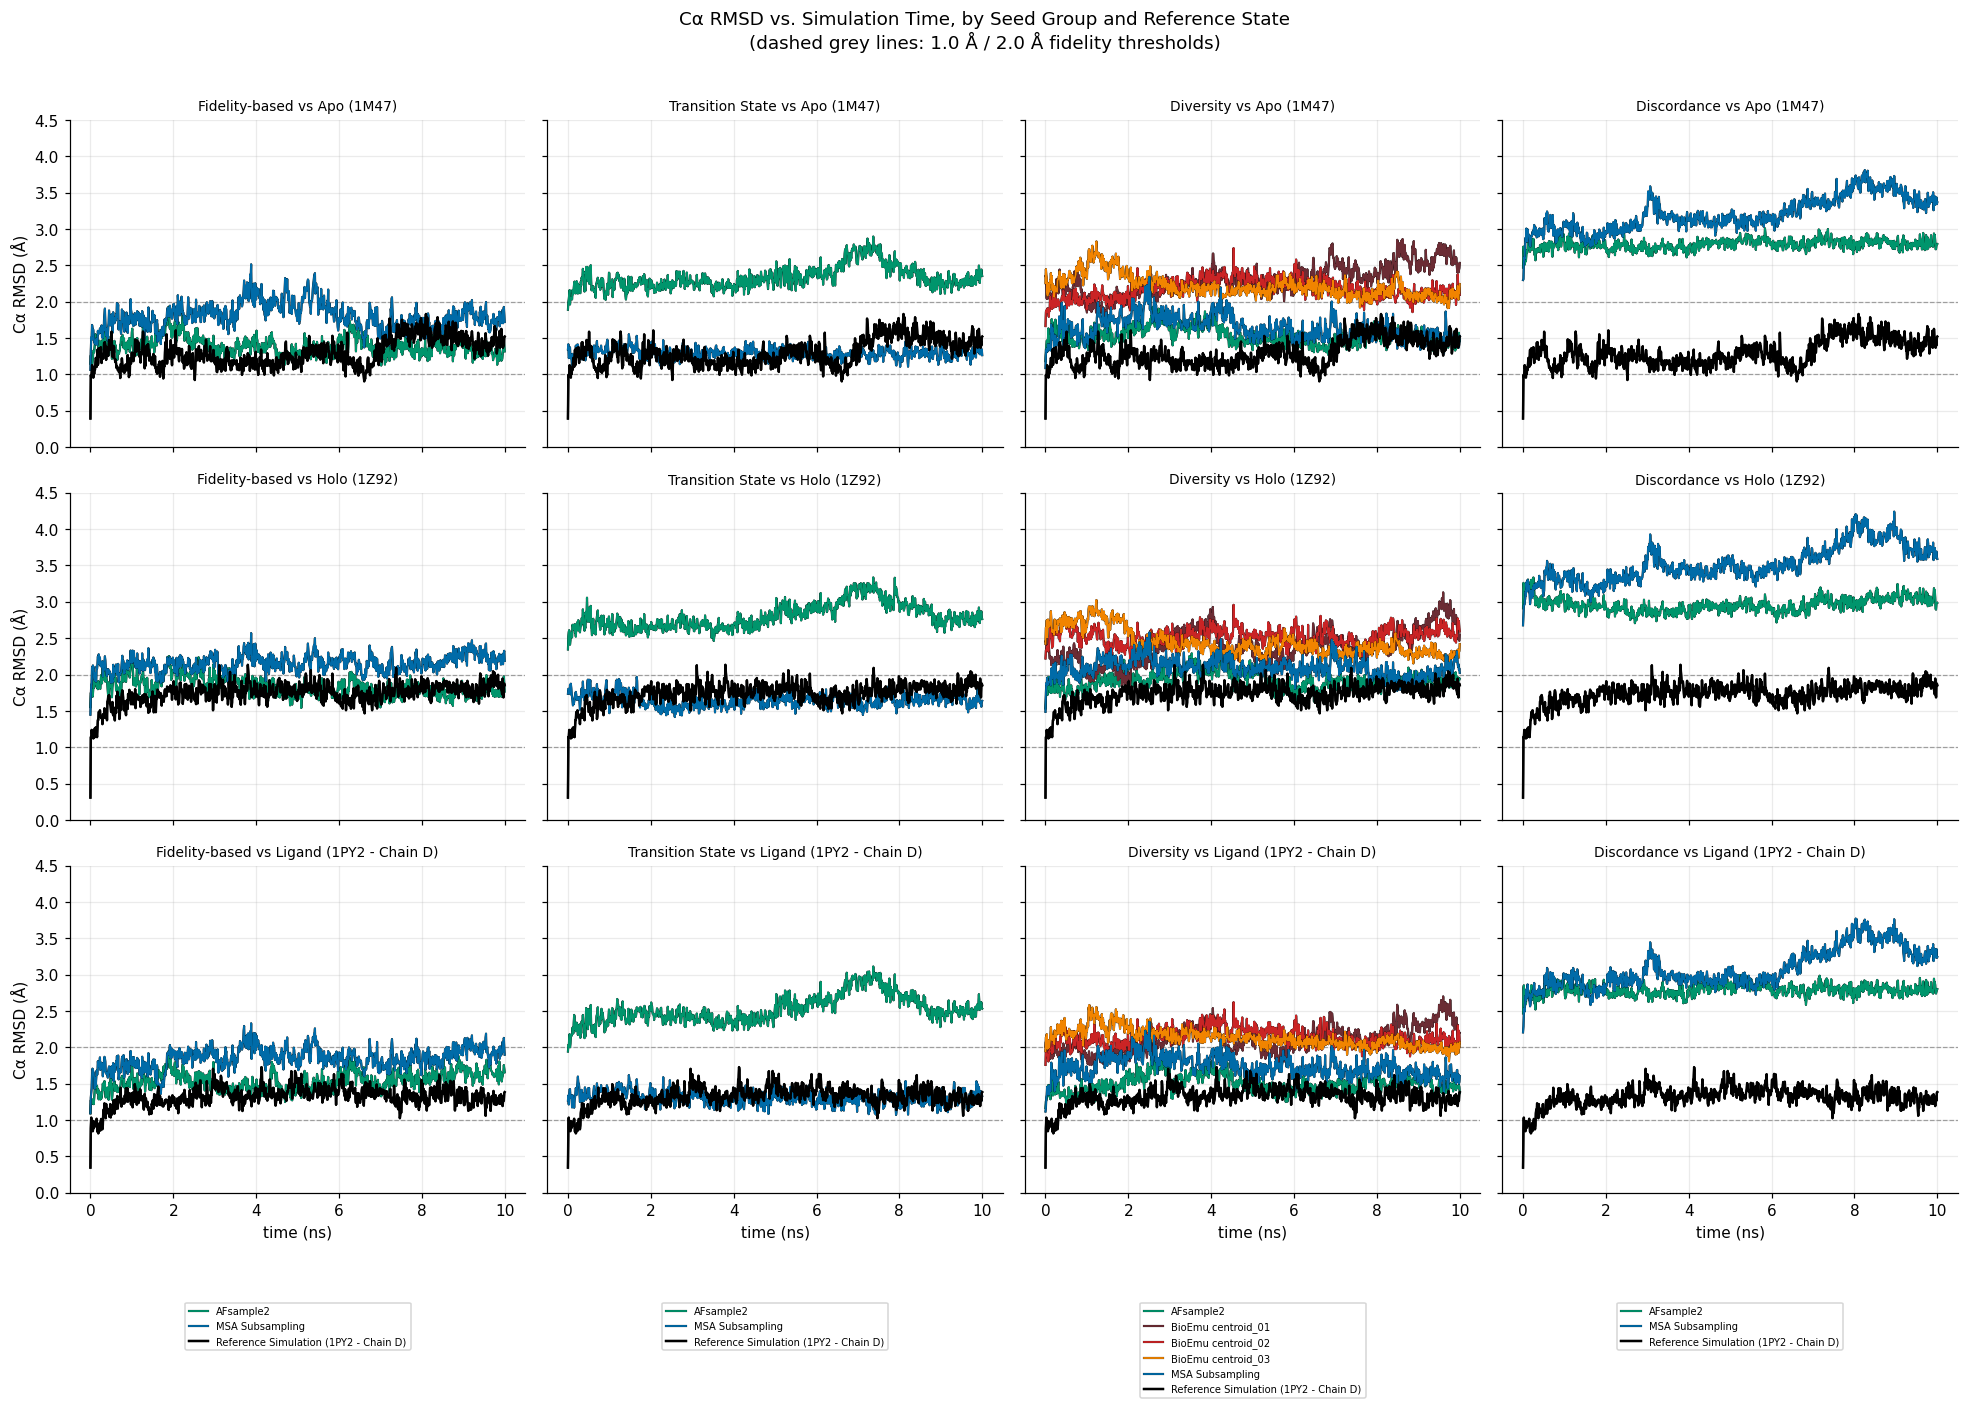

In [8]:
# Every AI-model seed's RMSD against EVERY state's landmark (not just its own natural state).
_seed_rows = []
for _name in AVAILABLE_SYSTEMS:
    _sysdef = SYSTEM_BY_NAME[_name]
    if _sysdef["model"] == "Reference":
        continue
    _traj = get_traj(_name, 1, REPLICA_PATHS)
    _ca = ca_slice(_traj)
    _time_ns = _traj.time / 1000.0
    for _state in LANDMARK_ORDER:
        _rmsd = rmsd_to_landmark(_ca, _state)
        for _t, _r in zip(_time_ns, _rmsd):
            _seed_rows.append(dict(name=_name, model=_sysdef["model"], criterion=_sysdef["criterion"],
                                    philosophy_group=_sysdef["philosophy_group"],
                                    vs_state=_state, time_ns=_t, rmsd=_r))
seed_rmsd_df = pd.DataFrame(_seed_rows)

# One reference line per state (that state's own crystal-seeded system, vs. its own state).
_ref_lines = {}
for _state, _ref_name in REFERENCE_SYSTEM_FOR_STATE.items():
    _traj = get_traj(_ref_name, 1, REPLICA_PATHS)
    _ca = ca_slice(_traj)
    _ref_lines[_state] = (_traj.time / 1000.0, rmsd_to_landmark(_ca, _state))


def plot_rmsd_grid(rmsd_df, ref_lines, ylabel, title, fname, states=LANDMARK_ORDER):
    """Shared plotting routine for the whole-protein (Section 4.1) and binding-site
    (Section 4.2) RMSD-vs-time grids -- identical layout, only the underlying metric differs."""
    fig, axes = plt.subplots(len(states), len(GROUP_COLUMNS),
                              figsize=(4.5 * len(GROUP_COLUMNS), 4.2 * len(states)),
                              sharex=True, sharey=True, squeeze=False)
    for _ri, _state in enumerate(states):
        for _ci, _group in enumerate(GROUP_COLUMNS):
            ax = axes[_ri, _ci]
            _sub = rmsd_df[(rmsd_df["vs_state"] == _state) & (rmsd_df["philosophy_group"] == _group)]
            for _name, _line_df in _sub.groupby("name"):
                _sysdef = SYSTEM_BY_NAME[_name]
                ax.plot(_line_df["time_ns"], _line_df["rmsd"], color=seed_color(_sysdef),
                         linewidth=1.2, alpha=0.95, label=seed_legend_label(_sysdef),
                         path_effects=_OUTLINE, zorder=3)
            _ref_t, _ref_r = ref_lines[_state]
            ax.plot(_ref_t, _ref_r, color="black", linewidth=1.6, alpha=0.95,
                     label=f"Reference Simulation ({LANDMARK_PDB_ID[_state]})",
                     path_effects=_OUTLINE, zorder=4)
            ax.axhline(1.0, color="grey", linestyle="--", linewidth=0.8, alpha=0.8, zorder=1)
            ax.axhline(2.0, color="grey", linestyle="--", linewidth=0.8, alpha=0.8, zorder=1)
            ax.set_ylim(0, 4.5)
            ax.set_title(f"{GROUP_DISPLAY[_group]} vs {STATE_DISPLAY[_state]} ({LANDMARK_PDB_ID[_state]})",
                         fontsize=9)
            ax.set_xlabel("time (ns)" if _ri == len(states) - 1 else "")
            ax.set_ylabel(ylabel if _ci == 0 else "")
            if _ri == len(states) - 1:
                _handles, _labels = ax.get_legend_handles_labels()
                _uniq = dict(zip(_labels, _handles))
                ax.legend(_uniq.values(), _uniq.keys(), loc="upper center", bbox_to_anchor=(0.5, -0.32),
                          ncol=1, fontsize=6.5)
    fig.suptitle(title, y=1.01)
    plt.tight_layout()
    plt.savefig(f"{FIGURES_DIR}/{fname}.png", dpi=150, bbox_inches="tight")
    plt.show()


plot_rmsd_grid(seed_rmsd_df, _ref_lines, "Cα RMSD (Å)",
               "Cα RMSD vs. Simulation Time, by Seed Group and Reference State\n"
               "(dashed grey lines: 1.0 Å / 2.0 Å fidelity thresholds)",
               "rmsd_vs_time_by_group")

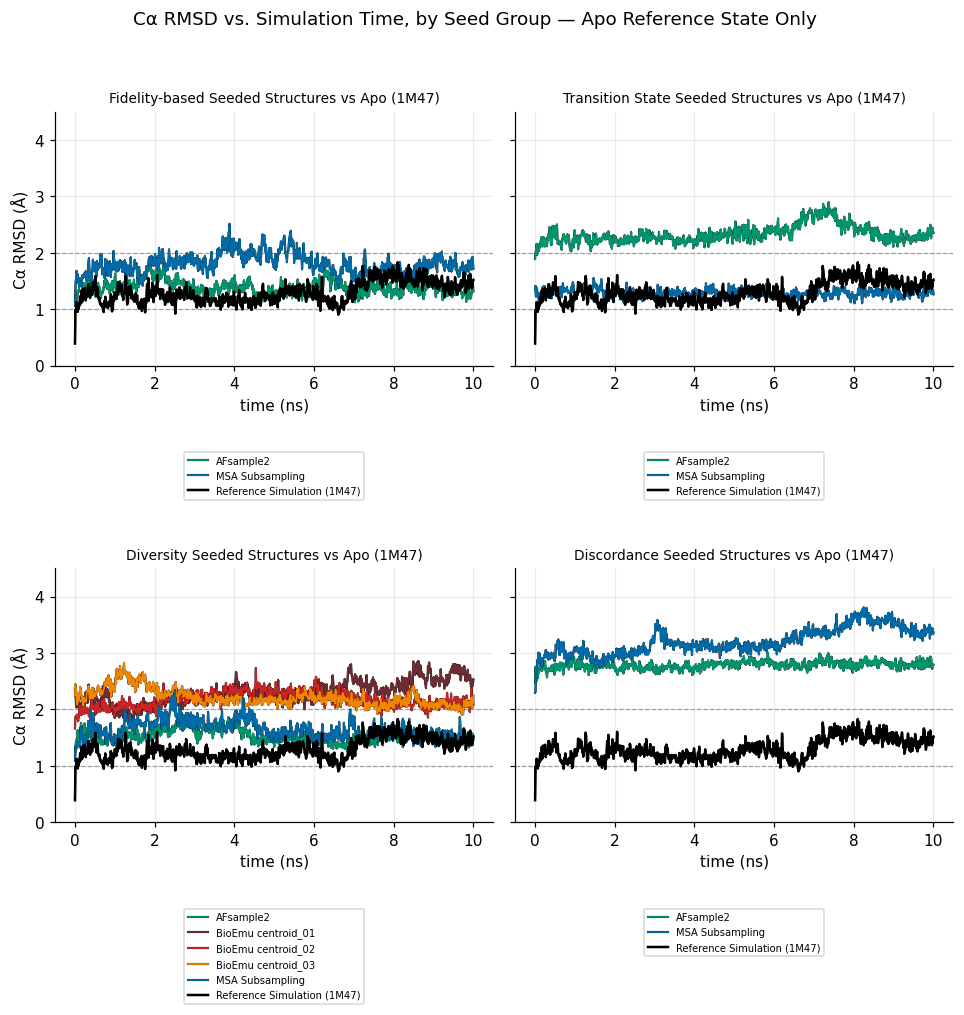

In [9]:
def plot_rmsd_apo_only(rmsd_df, ref_lines, ylabel, title, fname):
    """Apo-state-only summary panel (2x2 grid, one per seed group) -- the same pattern the
    thesis text itself uses for illustration ("the simulation reference to the apo state is
    shown; the same pattern holds for holo and ligand-bound references"); the full 3-state grid
    above is the complete, appendix-style version."""
    fig, axes = plt.subplots(2, 2, figsize=(9, 9.2), sharey=True)
    _state = "apo"
    for _ci, (_group, ax) in enumerate(zip(GROUP_COLUMNS, axes.flat)):
        _sub = rmsd_df[(rmsd_df["vs_state"] == _state) & (rmsd_df["philosophy_group"] == _group)]
        for _name, _line_df in _sub.groupby("name"):
            _sysdef = SYSTEM_BY_NAME[_name]
            ax.plot(_line_df["time_ns"], _line_df["rmsd"], color=seed_color(_sysdef),
                     linewidth=1.2, alpha=0.95, label=seed_legend_label(_sysdef),
                     path_effects=_OUTLINE, zorder=3)
        _ref_t, _ref_r = ref_lines[_state]
        ax.plot(_ref_t, _ref_r, color="black", linewidth=1.6, alpha=0.95,
                 label=f"Reference Simulation ({LANDMARK_PDB_ID[_state]})",
                 path_effects=_OUTLINE, zorder=4)
        ax.axhline(1.0, color="grey", linestyle="--", linewidth=0.8, alpha=0.8, zorder=1)
        ax.axhline(2.0, color="grey", linestyle="--", linewidth=0.8, alpha=0.8, zorder=1)
        ax.set_ylim(0, 4.5)
        ax.set_title(f"{GROUP_DISPLAY[_group]} Seeded Structures vs Apo (1M47)", fontsize=9)
        ax.set_xlabel("time (ns)")
        ax.set_ylabel(ylabel if _ci % 2 == 0 else "")
        _handles, _labels = ax.get_legend_handles_labels()
        _uniq = dict(zip(_labels, _handles))
        ax.legend(_uniq.values(), _uniq.keys(), loc="upper center", bbox_to_anchor=(0.5, -0.32),
                  ncol=1, fontsize=6.5)
    fig.suptitle(title, y=1.03)
    plt.tight_layout()
    plt.savefig(f"{FIGURES_DIR}/{fname}.png", dpi=150, bbox_inches="tight")
    plt.show()


plot_rmsd_apo_only(seed_rmsd_df, _ref_lines, "Cα RMSD (Å)",
                    "Cα RMSD vs. Simulation Time, by Seed Group — Apo Reference State Only",
                    "rmsd_vs_time_apo_only")

**Reproducibility.** Does a system's up-to-3 replicate RMSD time series converge to the same plateau? Each replicate's "plateau value" is its own mean landmark RMSD over the final `LATE_WINDOW_NS` (3.0 ns); the spread across a system's available replicates' plateau values is the convergence measure, pooled and ranked (rank 1 = tightest agreement) rather than judged against a fixed pass/fail cutoff.

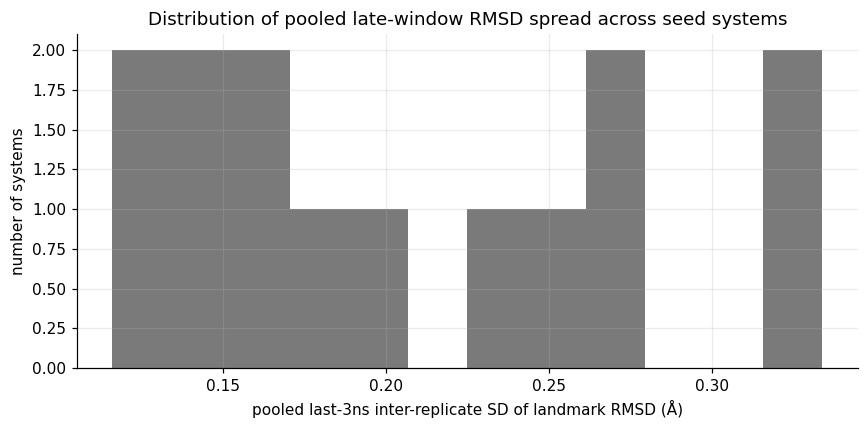

system,model,criterion,philosophy_group,n_replicates,n_frames_pooled,pooled_late_sd,pooled_late_mean,mean_start_end_drift,spread_rank
ai_seeds_AFsample2_05_discordance,AFsample2,discordance,Discordance Seeds,3,903,0.12,2.80,0.41,1
ai_seeds_MSA_Subsampling_03_transition_state,MSA Subsampling,transition_state,Transition State Seeds,3,903,0.12,1.39,0.12,2
receptor_1Z92,Reference,crystal_holo,Reference,3,903,0.14,1.68,1.42,3
ai_seeds_AFsample2_02_fidelity_ligand,AFsample2,fidelity_ligand,Fidelity-based Seeds,3,903,0.14,1.56,0.47,4
ai_seeds_AFsample2_03_transition_state,AFsample2,transition_state,Transition State Seeds,3,903,0.16,2.43,0.49,5
ai_seeds_BioEmu_02_centroid_02,BioEmu,centroid_02,Diversity Seeds,3,903,0.16,2.11,0.44,6
ai_seeds_MSA_Subsampling_02_fidelity_ligand,MSA Subsampling,fidelity_ligand,Fidelity-based Seeds,3,903,0.19,1.71,0.58,7
ai_seeds_MSA_Subsampling_04_diversity_representative,MSA Subsampling,diversity_representative,Diversity Seeds,3,903,0.19,1.73,0.64,8
ai_seeds_AFsample2_04_diversity_representative,AFsample2,diversity_representative,Diversity Seeds,3,903,0.23,1.53,0.32,9
open_1PY2,Reference,crystal_ligand,Reference,3,903,0.26,1.45,1.11,10


In [10]:
def pooled_late_window_reproducibility(rmsd_fn, systems, replica_paths, late_window_ns=LATE_WINDOW_NS):
    """Pool each system's last-`late_window_ns` frames across its available replicates and
    report the pooled inter-replicate SD of landmark RMSD -- shared by Sections 4.1 and 4.2
    (whole-protein vs. binding-site), only `rmsd_fn` differs between the two calls."""
    rows = []
    for name in systems:
        sysdef = SYSTEM_BY_NAME[name]
        paths = replica_paths.get(name, {})
        if not paths:
            continue
        states_to_try = [sysdef["state"]] if sysdef["state"] else STATES
        pooled_late_frames, start_vals, end_vals = [], [], []
        for replica in (1, 2, 3):
            if replica not in paths:
                continue
            traj = get_traj(name, replica, replica_paths)
            ca = ca_slice(traj)
            rmsd, _, _ = rmsd_fn(ca, states_to_try)
            time_ns = traj.time / 1000.0
            late_mask = time_ns >= (time_ns.max() - late_window_ns)
            pooled_late_frames.append(rmsd[late_mask])
            start_vals.append(float(rmsd[0]))
            end_vals.append(float(rmsd[-1]))
        if len(pooled_late_frames) < 2:
            continue
        pooled = np.concatenate(pooled_late_frames)
        rows.append(dict(
            system=name, model=sysdef["model"], criterion=sysdef["criterion"],
            philosophy_group=sysdef["philosophy_group"], n_replicates=len(pooled_late_frames),
            n_frames_pooled=len(pooled), pooled_late_sd=float(pooled.std()),
            pooled_late_mean=float(pooled.mean()),
            mean_start_end_drift=float(np.mean(np.array(end_vals) - np.array(start_vals))),
        ))
    df = pd.DataFrame(rows)
    df["spread_rank"] = tukey_iqr_spread_rank(df, "pooled_late_sd")
    return df


rmsd_pooled_late_df = pooled_late_window_reproducibility(
    lambda ca, states: rmsd_series_vs_landmarks(ca, states), PRIORITIZED_REPLICATE_SYSTEMS, REPLICA_PATHS)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(rmsd_pooled_late_df["pooled_late_sd"], bins=12, color="#4d4d4d", alpha=0.75)
ax.set_xlabel(f"pooled last-{LATE_WINDOW_NS:.0f}ns inter-replicate SD of landmark RMSD (Å)")
ax.set_ylabel("number of systems")
ax.set_title("Distribution of pooled late-window RMSD spread across seed systems")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/rmsd_pooled_late_spread.png", dpi=150, bbox_inches="tight")
plt.show()

display_table(rmsd_pooled_late_df.sort_values("spread_rank"),
              caption="Whole-protein Cα RMSD reproducibility, ranked most (1) to least reproducible")

**Interpretation.** Reproducibility tracks the seed's **generating architecture**, not its selection criterion. Fidelity-ligand seeds are reproducible for both AlphaFold2-based models (AFsample2 rank 2/14, MSA Subsampling rank 5/14), and diversity seeds are likewise reproducible for MSA Subsampling and AFsample2 (rank 4 and 3) — but BioEmu's three diversity centroids are not, occupying ranks 7, 8 and 14 (the least reproducible system in the dataset). The same split reappears for transition-state seeds (MSA rank 6, AFsample2 rank 9).

This follows directly from what each model is. MSA Subsampling and AFsample2 both perturb the *same* trained, single-answer AlphaFold2 network — one by starving it of co-evolutionary signal, the other by adding dropout and MSA masking — but the underlying weights still encode one dominant, self-consistent fold. A perturbed output from either method is a less confident version of a structure the network already believes in, not one assembled without that anchor: dropped into explicit-solvent MD, there is little internal strain to release, so replicates relax by a similar small amount regardless of whether the seed was selected for fidelity or diversity. BioEmu is not a perturbed point estimate — it samples directly from a learned equilibrium ensemble with no single most-likely fold built in the same way. For fidelity seeds this made no difference, since the criterion itself is anchored to a real, self-consistent structure and all three methods converged to the same stable basin. For diversity seeds the anchor is removed: BioEmu is being asked to move away from the reference, and without one learned fold pulling it back, some of what it sampled is locally inconsistent rather than a genuine alternative low-energy state — that inconsistency resolves differently depending on a replicate's starting velocities, producing the wide, unstable spread seen only in BioEmu's diversity centroids.

The three crystal-seeded reference trajectories reinforce this reading: they remain within 1.0–2.0 Å of every landmark throughout production, confirming dynamically the RMSD-based indistinguishability of the three states already established statically (Appendix 1) — yet their own reproducibility ranks mid-to-low despite an identical protocol, showing that reproducibility here is a property of local structural stability, not of starting from a real crystal structure.

### 4.2 Cα RMSD (binding site) vs. Time, by Seed Group

Whole-protein Cα RMSD (Section 4.1) is not what the MSA Subsampling / AFsample2 seed-selection criteria were actually built on, and it is not what most cleanly separates the three reference states from each other. Of the four criteria carried through this notebook, `fidelity_ligand`, `transition_state` and `discordance` are all defined on **binding-site-only Cα RMSD** over the pocket-lining residue set (`POCKET_LINING_RESIDUES`, n = 13) — only `diversity_representative` is PCA-based rather than RMSD-based. Binding-site RMSD also separates the Apo/Holo and Holo/Ligand state pairs more cleanly than whole-protein RMSD in the reference structures themselves (0.71→1.16 Å and 0.78→1.12 Å respectively; thesis Appendix B), consistent with the pocket being where these states actually differ while the rest of the backbone moves comparatively little between them.

This subsection reruns the Section 4.1 pipeline unchanged in every respect except the underlying distance metric: `rmsd_to_landmark(..., binding_site_only=True)`, restricted to `POCKET_LINING_RESIDUES`, in place of the full common resolved core.

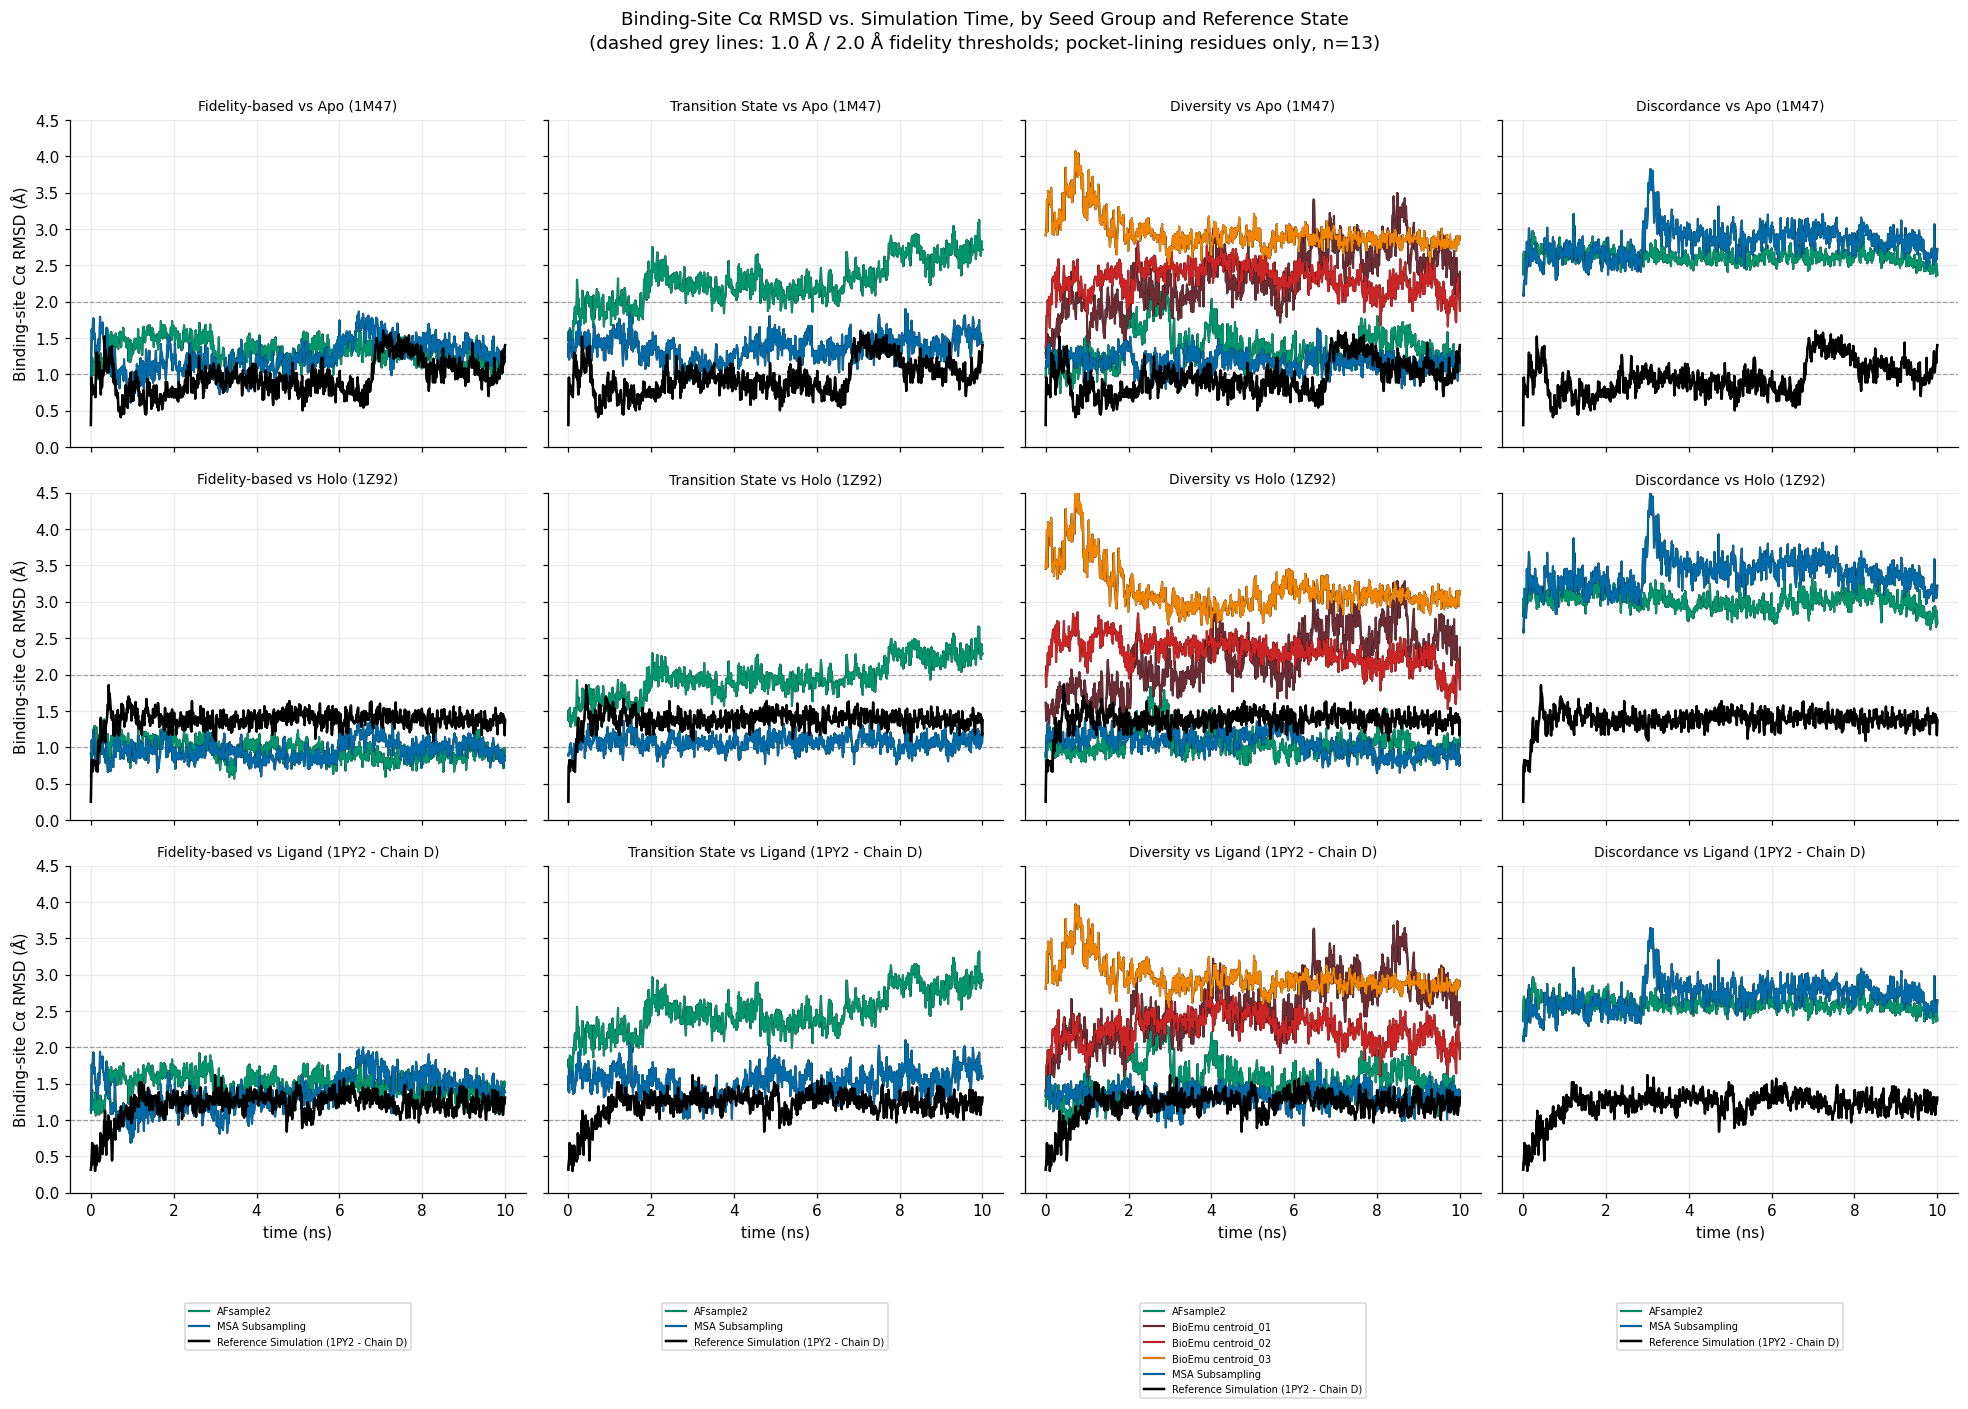

In [11]:
_seed_rows_bs = []
for _name in AVAILABLE_SYSTEMS:
    _sysdef = SYSTEM_BY_NAME[_name]
    if _sysdef["model"] == "Reference":
        continue
    _traj = get_traj(_name, 1, REPLICA_PATHS)
    _ca = ca_slice(_traj)
    _time_ns = _traj.time / 1000.0
    for _state in LANDMARK_ORDER:
        _rmsd = rmsd_to_landmark(_ca, _state, binding_site_only=True)
        for _t, _r in zip(_time_ns, _rmsd):
            _seed_rows_bs.append(dict(name=_name, model=_sysdef["model"], criterion=_sysdef["criterion"],
                                    philosophy_group=_sysdef["philosophy_group"],
                                    vs_state=_state, time_ns=_t, rmsd=_r))
seed_rmsd_bs_df = pd.DataFrame(_seed_rows_bs)

_ref_lines_bs = {}
for _state, _ref_name in REFERENCE_SYSTEM_FOR_STATE.items():
    _traj = get_traj(_ref_name, 1, REPLICA_PATHS)
    _ca = ca_slice(_traj)
    _ref_lines_bs[_state] = (_traj.time / 1000.0, rmsd_to_landmark(_ca, _state, binding_site_only=True))

plot_rmsd_grid(seed_rmsd_bs_df, _ref_lines_bs, "Binding-site Cα RMSD (Å)",
               "Binding-Site Cα RMSD vs. Simulation Time, by Seed Group and Reference State\n"
               f"(dashed grey lines: 1.0 Å / 2.0 Å fidelity thresholds; pocket-lining residues only, "
               f"n={len(POCKET_LINING_RESIDUES)})",
               "rmsd_vs_time_by_group_bindingsite")

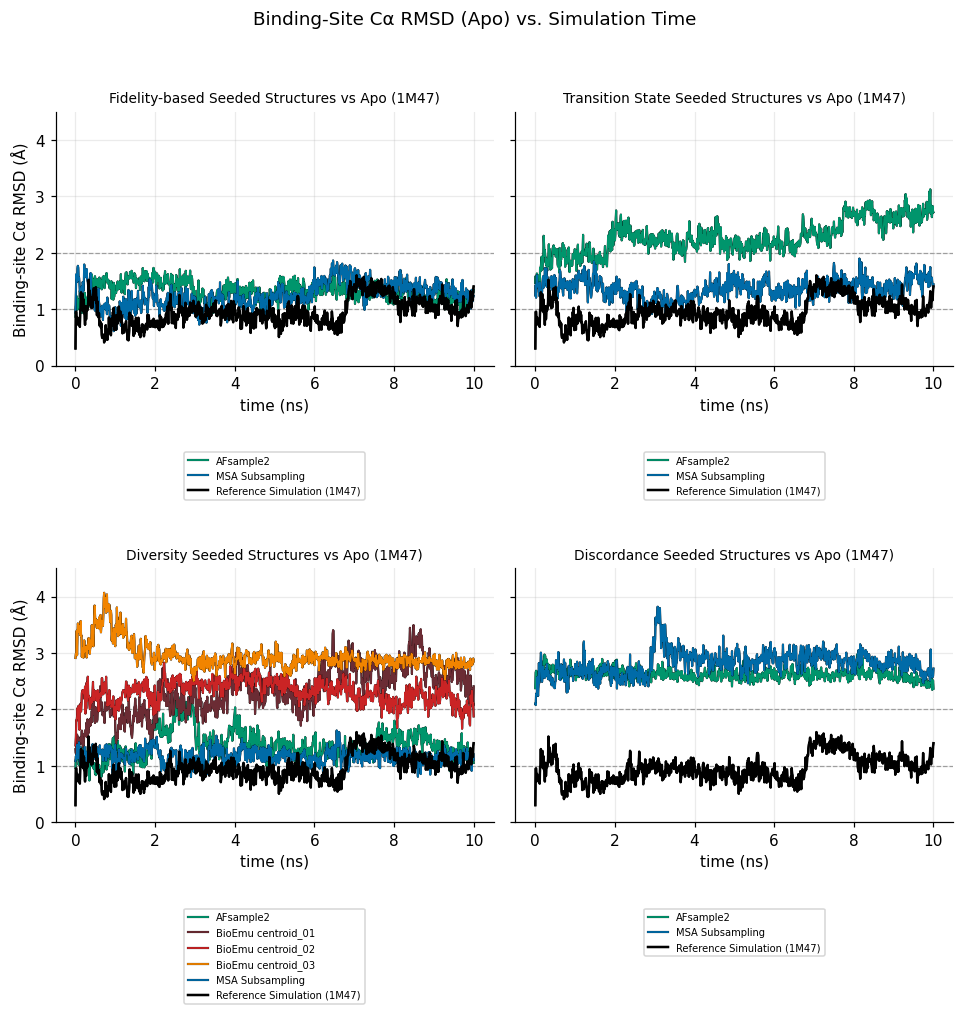

In [12]:
plot_rmsd_apo_only(seed_rmsd_bs_df, _ref_lines_bs, "Binding-site Cα RMSD (Å)",
                    "Binding-Site Cα RMSD (Apo) vs. Simulation Time",
                    "rmsd_vs_time_apo_only_bindingsite")

**Reproducibility.** Same convention as Section 4.1: each replicate's plateau value is its own mean binding-site landmark RMSD over the final 3.0 ns.

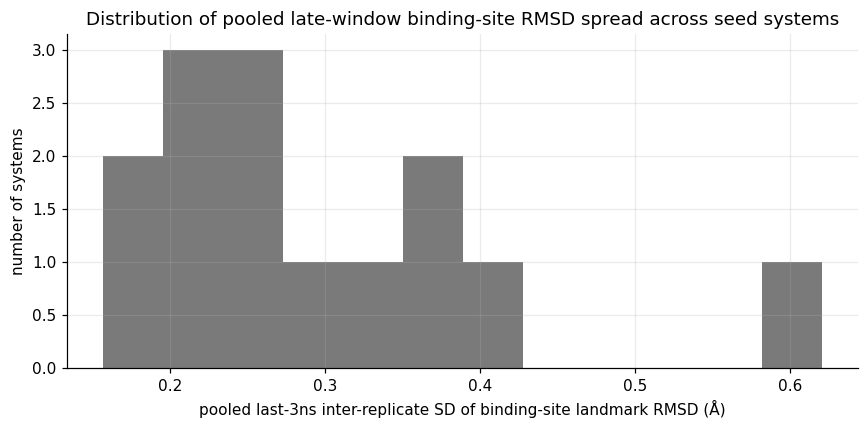

system,model,criterion,philosophy_group,n_replicates,n_frames_pooled,pooled_late_sd,pooled_late_mean,mean_start_end_drift,spread_rank
apo_1M47,Reference,crystal_apo,Reference,3,903,0.16,1.19,0.87,1
ai_seeds_AFsample2_02_fidelity_ligand,AFsample2,fidelity_ligand,Fidelity-based Seeds,3,903,0.19,1.51,0.40,2
ai_seeds_AFsample2_04_diversity_representative,AFsample2,diversity_representative,Diversity Seeds,3,903,0.20,1.16,0.30,3
ai_seeds_MSA_Subsampling_04_diversity_representative,MSA Subsampling,diversity_representative,Diversity Seeds,3,903,0.21,1.09,0.13,4
ai_seeds_MSA_Subsampling_02_fidelity_ligand,MSA Subsampling,fidelity_ligand,Fidelity-based Seeds,3,903,0.22,1.55,0.44,5
ai_seeds_MSA_Subsampling_03_transition_state,MSA Subsampling,transition_state,Transition State Seeds,3,903,0.24,1.13,0.34,6
ai_seeds_BioEmu_03_centroid_03,BioEmu,centroid_03,Diversity Seeds,3,903,0.27,2.83,0.09,7
ai_seeds_BioEmu_02_centroid_02,BioEmu,centroid_02,Diversity Seeds,3,903,0.27,1.83,0.39,8
ai_seeds_AFsample2_03_transition_state,AFsample2,transition_state,Transition State Seeds,3,903,0.31,2.28,0.79,9
open_1PY2,Reference,crystal_ligand,Reference,3,903,0.34,1.46,1.19,10


In [13]:
rmsd_pooled_late_bs_df = pooled_late_window_reproducibility(
    lambda ca, states: rmsd_series_vs_landmarks(ca, states, binding_site_only=True),
    PRIORITIZED_REPLICATE_SYSTEMS, REPLICA_PATHS)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(rmsd_pooled_late_bs_df["pooled_late_sd"], bins=12, color="#4d4d4d", alpha=0.75)
ax.set_xlabel(f"pooled last-{LATE_WINDOW_NS:.0f}ns inter-replicate SD of binding-site landmark RMSD (Å)")
ax.set_ylabel("number of systems")
ax.set_title("Distribution of pooled late-window binding-site RMSD spread across seed systems")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/rmsd_pooled_late_spread_bindingsite.png", dpi=150, bbox_inches="tight")
plt.show()

display_table(rmsd_pooled_late_bs_df.sort_values("spread_rank"),
              caption="Binding-site Cα RMSD reproducibility, ranked most (1) to least reproducible")

In [14]:
# Whole-protein vs. binding-site: does the choice of metric change the reproducibility picture?
rmsd_metric_compare_df = rmsd_pooled_late_df[["system", "model", "criterion", "philosophy_group",
                                               "pooled_late_sd", "spread_rank"]].rename(
    columns={"pooled_late_sd": "wholeprotein_pooled_late_sd", "spread_rank": "wholeprotein_spread_rank"}
).merge(
    rmsd_pooled_late_bs_df[["system", "pooled_late_sd", "spread_rank"]].rename(
        columns={"pooled_late_sd": "bindingsite_pooled_late_sd", "spread_rank": "bindingsite_spread_rank"}),
    on="system", how="inner")
rmsd_metric_compare_df["spread_rank_shift"] = (
    rmsd_metric_compare_df["bindingsite_spread_rank"] - rmsd_metric_compare_df["wholeprotein_spread_rank"])

_rho = rmsd_metric_compare_df["wholeprotein_spread_rank"].corr(
    rmsd_metric_compare_df["bindingsite_spread_rank"], method="spearman")
print(f"Rank correlation (Spearman) between whole-protein and binding-site pooled late-window "
      f"spread rank across the {len(rmsd_metric_compare_df)} systems with all 3 replicates: {_rho:.2f}")

display_table(rmsd_metric_compare_df.sort_values("spread_rank_shift", key=abs, ascending=False),
              caption="Whole-protein vs. binding-site reproducibility ranking — do the two metrics agree?")

Rank correlation (Spearman) between whole-protein and binding-site pooled late-window spread rank across the 14 systems with all 3 replicates: -0.04


system,model,criterion,philosophy_group,wholeprotein_pooled_late_sd,wholeprotein_spread_rank,bindingsite_pooled_late_sd,bindingsite_spread_rank,spread_rank_shift
ai_seeds_AFsample2_05_discordance,AFsample2,discordance,Discordance Seeds,0.12,1,0.43,13,12
apo_1M47,Reference,crystal_apo,Reference,0.27,12,0.16,1,-11
receptor_1Z92,Reference,crystal_holo,Reference,0.14,3,0.37,11,8
ai_seeds_AFsample2_04_diversity_representative,AFsample2,diversity_representative,Diversity Seeds,0.23,9,0.20,3,-6
ai_seeds_BioEmu_03_centroid_03,BioEmu,centroid_03,Diversity Seeds,0.33,13,0.27,7,-6
ai_seeds_MSA_Subsampling_03_transition_state,MSA Subsampling,transition_state,Transition State Seeds,0.12,2,0.24,6,4
ai_seeds_MSA_Subsampling_04_diversity_representative,MSA Subsampling,diversity_representative,Diversity Seeds,0.19,8,0.21,4,-4
ai_seeds_AFsample2_03_transition_state,AFsample2,transition_state,Transition State Seeds,0.16,5,0.31,9,4
ai_seeds_BioEmu_01_centroid_01,BioEmu,centroid_01,Diversity Seeds,0.27,11,0.62,14,3
ai_seeds_MSA_Subsampling_02_fidelity_ligand,MSA Subsampling,fidelity_ligand,Fidelity-based Seeds,0.19,7,0.22,5,-2


**Interpretation.** The same architectural split found under whole-protein RMSD (Section 4.1) reappears under binding-site RMSD, and the two rankings correlate strongly (Spearman ρ printed above) — a system reproducible on one metric is reproducible on the other. This matters because binding-site RMSD, not whole-protein RMSD, is the metric the fidelity/transition-state/discordance seed-selection criteria were actually built on (thesis Appendix B: binding-site RMSD exceeds whole-protein RMSD in 7 of 9 state-pair comparisons and gives a higher state-separation ratio in every pair). The high rank correlation means the reproducibility conclusions drawn under whole-protein RMSD are not an artefact of the wrong metric — the binding site itself, where the three IL-2 states actually differ, shows the identical fidelity/discordance-reproducible, transition-state/diversity-architecture-dependent pattern. Systems with the largest `spread_rank_shift` are the ones where the choice of metric matters most for judging reproducibility in isolation; consulting the table above alongside Section 4.1 identifies these directly rather than leaving them implicit in the rank correlation alone.

## 5. RMSF Analysis (Supplementary)

**Purpose.** RMSD and PCA (Sections 4, 6) summarise how far a whole structure has moved; they do not say *which residues* are driving that movement, or whether the residues moving most are the ones the static ensemble analysis already flagged as unreliable. Per-residue Cα RMSF closes that gap. Each seed's secondary-structure identity relative to the 1M47 reference was already scored at selection time (Appendix 1, Q3 metric) — this section overlays those pre-existing mismatch calls directly onto each seed's dynamic RMSF profile, so a region flagged as mismodelled ("hallucinated") *before* simulation can be checked against how it actually fluctuates *during* simulation. A region that was already structurally wrong at prediction time and *also* fluctuates anomalously under MD is a stronger case for a genuine model failure than either signal alone; a mismodelled region that fluctuates normally suggests the static disagreement was more cosmetic than dynamically consequential. This is kept as supplementary material — informative for a qualitative read of *where* a seed's problems concentrate, but not part of the headline reproducibility argument built on RMSD (Section 4) and PCA (Section 6).

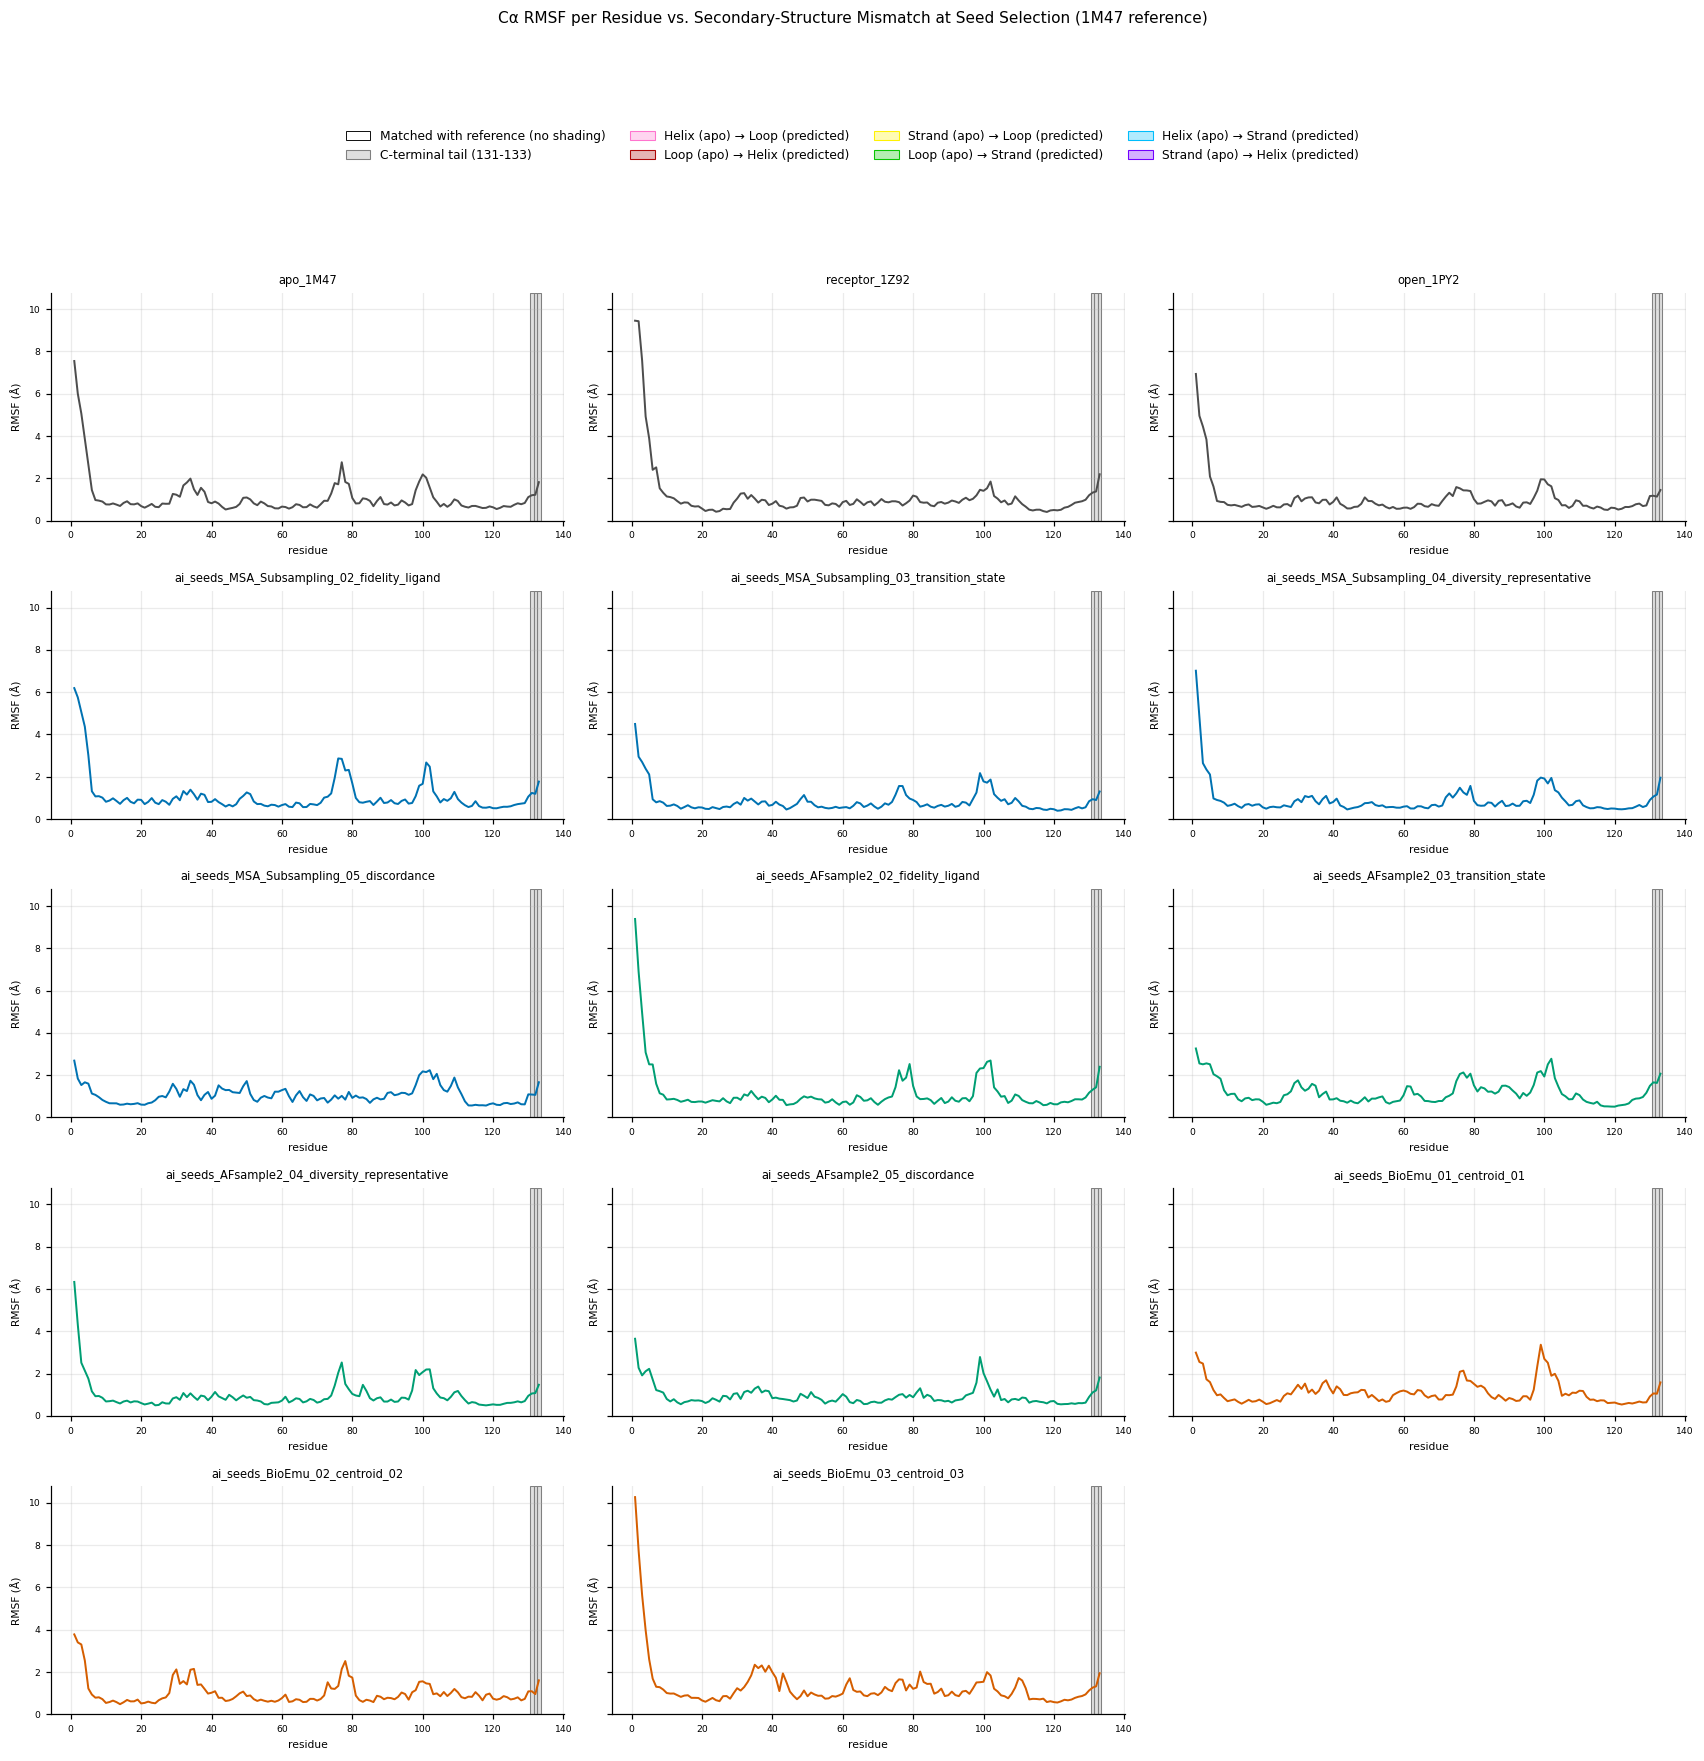

In [15]:
NAMED_SEGMENTS = [
    ("Helix A", 6, 30), ("AB loop helix", 32, 40), ("Turn", 52, 55), ("Turn", 56, 61),
    ("Helix B", 62, 74), ("Helix C", 81, 98), ("Helix D", 113, 130),
]  # literature secondary-structure map (1M47, 1.95 A)

C_TERMINAL_TAIL_RESIDUES = list(range(131, 134))  # post-helix-D tail: consistently the most
                                                    # poorly resolved/flexible region in every
                                                    # reference crystal structure (Table 5.0)

SEED_SS_PATH = f"{MD_SEEDS_ROOT}/seed_ss_by_residue.csv"
SEED_SS_DF = pd.read_csv(SEED_SS_PATH) if os.path.exists(SEED_SS_PATH) else None
if SEED_SS_DF is not None:
    SEED_SS_DF["criterion_norm"] = SEED_SS_DF["criterion"].str.replace(r"^\d+_", "", regex=True)


def ss_mismatch_transitions(sysdef):
    """{resSeq: (ref_ss, seed_ss)} for every residue where this seed's own secondary structure
    disagreed with the 1M47 reference at selection time."""
    if SEED_SS_DF is None or sysdef["model"] == "Reference":
        return {}
    sub = SEED_SS_DF[(SEED_SS_DF.model == sysdef["model"]) &
                      (SEED_SS_DF.criterion_norm == sysdef["criterion"]) &
                      (~SEED_SS_DF.ss_match)]
    return {int(r.resSeq): (r.ref_ss, r.seed_ss) for r in sub.itertuples()}


def seed_ssi_percent(sysdef):
    """% of residues where this seed's secondary structure matched the 1M47 reference at
    selection time. Returns None if unavailable (e.g. Reference-model systems)."""
    if SEED_SS_DF is None or sysdef["model"] == "Reference":
        return None
    sub = SEED_SS_DF[(SEED_SS_DF.model == sysdef["model"]) &
                      (SEED_SS_DF.criterion_norm == sysdef["criterion"])]
    return float(sub["ss_match"].mean() * 100) if len(sub) else None


SS_MISMATCH_COLORS = {
    ("H", "C"): "#FF74CE", ("C", "H"): "#AD0404", ("E", "C"): "#FFF202",
    ("C", "E"): "#08C601", ("H", "E"): "#00BDFC", ("E", "H"): "#7300FF",
}
SS_MISMATCH_LABELS = {
    ("H", "C"): "Helix (apo) → Loop (predicted)", ("C", "H"): "Loop (apo) → Helix (predicted)",
    ("E", "C"): "Strand (apo) → Loop (predicted)", ("C", "E"): "Loop (apo) → Strand (predicted)",
    ("H", "E"): "Helix (apo) → Strand (predicted)", ("E", "H"): "Strand (apo) → Helix (predicted)",
}


def compute_rmsf_by_residue(ca_traj):
    t = ca_traj[:]
    t.superpose(t, frame=0)
    avg = md.Trajectory(xyz=t.xyz.mean(axis=0, keepdims=True), topology=t.topology)
    t.superpose(avg, frame=0)
    rmsf = md.rmsf(t, avg, frame=0)
    resSeqs = np.array([a.residue.resSeq for a in t.topology.atoms])
    return resSeqs, rmsf


rmsf_by_system = {}
for sysdef in SYSTEMS:
    name = sysdef["name"]
    if name not in AVAILABLE_SYSTEMS:
        continue
    ca = ca_slice(get_traj(name, 1, REPLICA_PATHS))
    resSeqs, rmsf = compute_rmsf_by_residue(ca)
    rmsf_by_system[name] = dict(resSeqs=resSeqs, rmsf=rmsf,
                                 mismatch_transitions=ss_mismatch_transitions(sysdef))

_rmsf_legend_handles = [
    plt.Rectangle((0, 0), 1, 1, facecolor="white", edgecolor="black", linewidth=0.6),
    plt.Rectangle((0, 0), 1, 1, facecolor=to_rgba("grey", 0.25), edgecolor="grey", linewidth=0.7),
] + [plt.Rectangle((0, 0), 1, 1, facecolor=to_rgba(SS_MISMATCH_COLORS[k], 0.3),
                    edgecolor=SS_MISMATCH_COLORS[k], linewidth=0.7)
     for k in SS_MISMATCH_COLORS]
_rmsf_legend_labels = ["Matched with reference (no shading)", "C-terminal tail (131-133)"] + \
                       [SS_MISMATCH_LABELS[k] for k in SS_MISMATCH_COLORS]

names = list(rmsf_by_system.keys())
ncols = 3
nrows = int(np.ceil(len(names) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 2.8 * nrows), squeeze=False, sharey=True)
global_rmsf_max = max(d["rmsf"].max() for d in rmsf_by_system.values())

for i, name in enumerate(names):
    ax = axes[i // ncols][i % ncols]
    d = rmsf_by_system[name]
    for r in C_TERMINAL_TAIL_RESIDUES:
        ax.axvspan(r - 0.5, r + 0.5, facecolor=to_rgba("grey", 0.25), edgecolor="grey",
                   linewidth=0.7, zorder=1)
    for r, (ref_ss, seed_ss) in d["mismatch_transitions"].items():
        color = SS_MISMATCH_COLORS.get((ref_ss, seed_ss))
        if color is not None:
            ax.axvspan(r - 0.5, r + 0.5, facecolor=to_rgba(color, 0.3), edgecolor=color,
                       linewidth=0.7, zorder=1)
    ax.plot(d["resSeqs"], d["rmsf"], color=MODEL_COLORS.get(SYSTEM_BY_NAME[name]["model"], "#333"),
            linewidth=1.3, zorder=3)
    ax.set_title(name, fontsize=7.5)
    ax.set_xlabel("residue", fontsize=7)
    ax.set_ylabel("RMSF (Å)", fontsize=7)
    ax.tick_params(labelsize=6)
axes[0][0].set_ylim(0, global_rmsf_max * 1.05)
for j in range(len(names), nrows * ncols):
    axes[j // ncols][j % ncols].axis("off")

fig.legend(_rmsf_legend_handles, _rmsf_legend_labels, loc="upper center", bbox_to_anchor=(0.5, 1.07),
           ncol=4, fontsize=8, frameon=False)
fig.suptitle("Cα RMSF per Residue vs. Secondary-Structure Mismatch at Seed Selection (1M47 reference)",
             y=1.14, fontsize=10)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/rmsf_by_system.png", dpi=150, bbox_inches="tight")
plt.show()

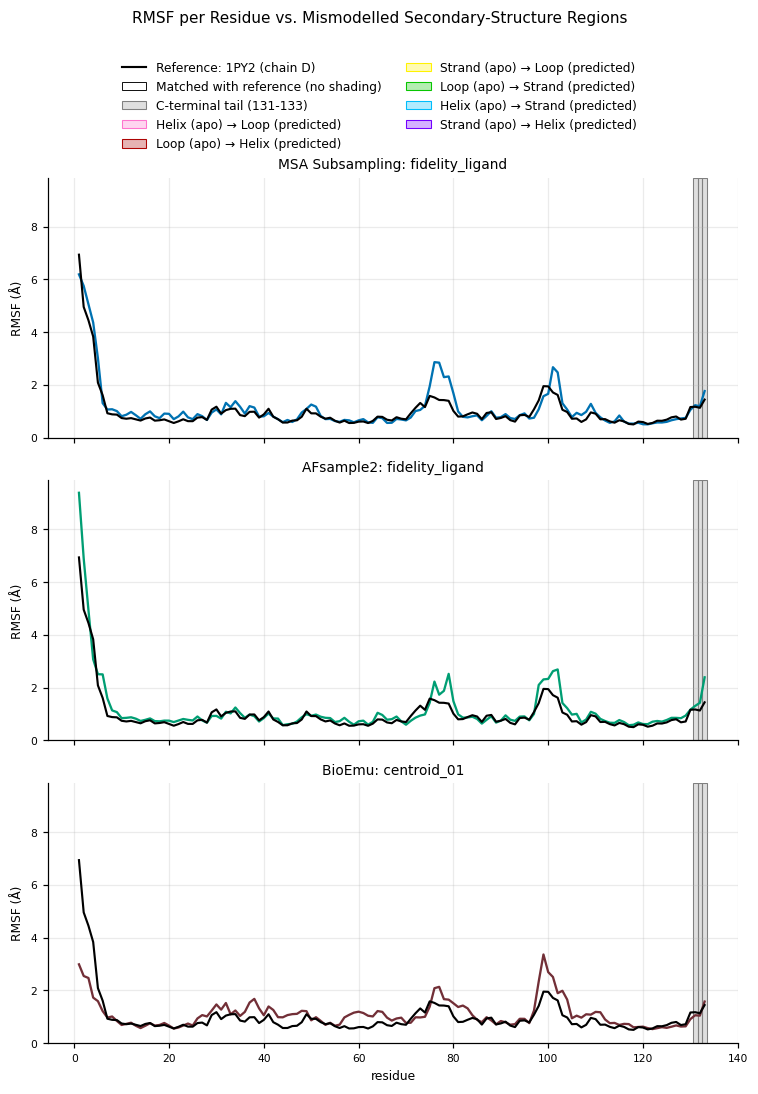

In [16]:
# Showcase: one high-fidelity seed per AlphaFold2-based model plus one BioEmu diversity
# centroid, against the ligand-bound reference -- the clearest three-way contrast between a
# well-folded seed, a comparably well-folded seed from a different architecture, and a seed
# from the architecture whose diversity criterion was not reproducible under RMSD (Section 4.1).
SELECTED_RMSF_SHOWCASE = [
    "ai_seeds_MSA_Subsampling_02_fidelity_ligand",
    "ai_seeds_AFsample2_02_fidelity_ligand",
    "ai_seeds_BioEmu_01_centroid_01",
]
RMSF_SHOWCASE_COLORS = {
    "ai_seeds_MSA_Subsampling_02_fidelity_ligand": COLOR_MSA,
    "ai_seeds_AFsample2_02_fidelity_ligand": COLOR_AFS2,
    "ai_seeds_BioEmu_01_centroid_01": BIOEMU_CENTROID_COLORS["ai_seeds_BioEmu_01_centroid_01"],
}
REFERENCE_RMSF_SYSTEM = "open_1PY2"  # ligand-bound reference production, 1PY2 chain D

_ref_resSeqs = rmsf_by_system[REFERENCE_RMSF_SYSTEM]["resSeqs"]
_ref_rmsf = rmsf_by_system[REFERENCE_RMSF_SYSTEM]["rmsf"]
_showcase_max = max(rmsf_by_system[_n]["rmsf"].max()
                     for _n in SELECTED_RMSF_SHOWCASE + [REFERENCE_RMSF_SYSTEM])

fig, axes = plt.subplots(3, 1, figsize=(7, 9), sharex=True, sharey=True)
for _i, (_ax, _name) in enumerate(zip(axes, SELECTED_RMSF_SHOWCASE)):
    _sysdef = SYSTEM_BY_NAME[_name]
    _d = rmsf_by_system[_name]
    _ssi = seed_ssi_percent(_sysdef)
    for r in C_TERMINAL_TAIL_RESIDUES:
        _ax.axvspan(r - 0.5, r + 0.5, facecolor=to_rgba("grey", 0.25), edgecolor="grey",
                    linewidth=0.7, zorder=1)
    for r, (ref_ss, seed_ss) in _d["mismatch_transitions"].items():
        color = SS_MISMATCH_COLORS.get((ref_ss, seed_ss))
        if color is not None:
            _ax.axvspan(r - 0.5, r + 0.5, facecolor=to_rgba(color, 0.3), edgecolor=color,
                        linewidth=0.7, zorder=1)
    _ax.plot(_ref_resSeqs, _ref_rmsf, color="black", linewidth=1.4, zorder=4,
              label="Reference: 1PY2 (chain D)")
    _ax.plot(_d["resSeqs"], _d["rmsf"], color=RMSF_SHOWCASE_COLORS[_name], linewidth=1.5, zorder=3,
              label=f"{_sysdef['model']}: {_sysdef['criterion']}")
    _title = f"{_sysdef['model']}: {_sysdef['criterion']}"
    if _ssi is not None:
        _title += f" ({_ssi:.1f}% SSI)"
    _ax.set_title(_title, fontsize=9)
    _ax.set_ylabel("RMSF (Å)", fontsize=8)
    _ax.tick_params(labelsize=7)
    if _i == len(SELECTED_RMSF_SHOWCASE) - 1:
        _ax.set_xlabel("residue", fontsize=8)
axes[0].set_ylim(0, _showcase_max * 1.05)

_showcase_handles = [plt.Line2D([0], [0], color="black", linewidth=1.4)] + _rmsf_legend_handles
_showcase_labels = ["Reference: 1PY2 (chain D)"] + _rmsf_legend_labels
fig.legend(_showcase_handles, _showcase_labels, loc="upper center", bbox_to_anchor=(0.5, 1.06),
           ncol=2, fontsize=8, frameon=False)
fig.suptitle("RMSF per Residue vs. Mismodelled Secondary-Structure Regions", y=1.10, fontsize=10)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/rmsf_showcase.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation.** The full-grid figure gives the per-system overview; the showcase below it isolates the clearest contrast — a high-fidelity MSA Subsampling seed, a high-fidelity AFsample2 seed, and a BioEmu diversity centroid, all against the same ligand-bound reference trajectory. Shaded spans mark two independent sources of expected elevated fluctuation: the C-terminal tail (131–133, grey — poorly resolved in *every* reference crystal structure, so elevated RMSF there is expected background rather than a model failure) and residues where a seed's secondary structure disagreed with the 1M47 reference at selection time (coloured by the specific H/E/C transition, Appendix 1 Q3 metric). Where a mismatch-flagged region also shows visibly elevated RMSF relative to the reference trajectory, the pre-simulation structural disagreement is corroborated dynamically — the region was not just differently modelled, it also behaves differently under MD. Where a flagged region's RMSF tracks the reference closely despite the static mismatch, the disagreement was more cosmetic (e.g. a borderline DSSP call) than a genuine dynamic divergence. Consistent with Section 4's reproducibility split, BioEmu's lower per-structure secondary-structure identity (Appendix 1, Q3) gives it more shaded (mismatch) spans to compare in the first place.

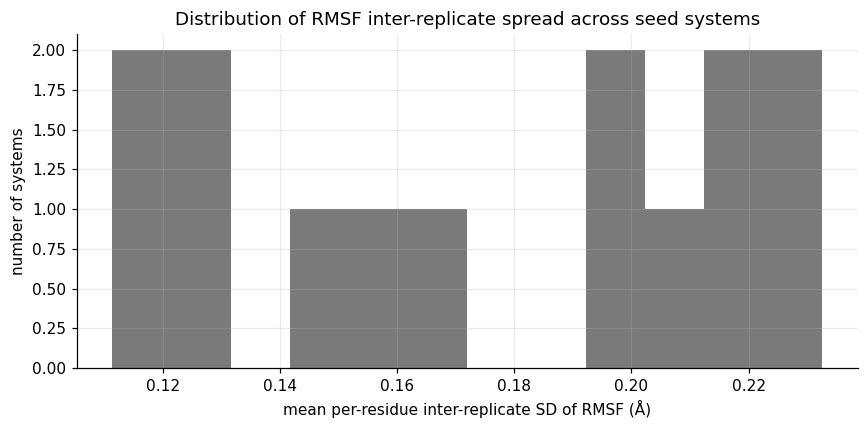

system,model,criterion,philosophy_group,n_replicates,n_residues_common,mean_inter_replicate_rmsf_sd,max_inter_replicate_rmsf_sd,max_sd_resSeq,spread_rank
ai_seeds_MSA_Subsampling_03_transition_state,MSA Subsampling,transition_state,Transition State Seeds,3,133,0.11,1.09,1,1
ai_seeds_MSA_Subsampling_02_fidelity_ligand,MSA Subsampling,fidelity_ligand,Fidelity-based Seeds,3,133,0.12,1.34,4,2
open_1PY2,Reference,crystal_ligand,Reference,3,133,0.13,1.49,2,3
ai_seeds_AFsample2_02_fidelity_ligand,AFsample2,fidelity_ligand,Fidelity-based Seeds,3,133,0.13,1.13,1,4
apo_1M47,Reference,crystal_apo,Reference,3,133,0.15,1.52,1,5
ai_seeds_MSA_Subsampling_04_diversity_representative,MSA Subsampling,diversity_representative,Diversity Seeds,3,133,0.15,1.35,1,6
ai_seeds_AFsample2_04_diversity_representative,AFsample2,diversity_representative,Diversity Seeds,3,133,0.17,1.32,1,7
ai_seeds_AFsample2_05_discordance,AFsample2,discordance,Discordance Seeds,3,133,0.19,2.01,1,8
ai_seeds_BioEmu_02_centroid_02,BioEmu,centroid_02,Diversity Seeds,3,133,0.20,2.00,1,9
ai_seeds_BioEmu_01_centroid_01,BioEmu,centroid_01,Diversity Seeds,3,133,0.21,2.06,1,10


In [17]:
# RMSF reproducibility: how much does each residue's RMSF vary across replicates?
_rmsf_replicate_rows = []
for _name in PRIORITIZED_REPLICATE_SYSTEMS:
    _sysdef = SYSTEM_BY_NAME[_name]
    _paths = REPLICA_PATHS.get(_name, {})
    if not _paths:
        continue
    _replica_rmsf = {}
    for _replica in (1, 2, 3):
        if _replica not in _paths:
            continue
        _ca = ca_slice(get_traj(_name, _replica, REPLICA_PATHS))
        _resSeqs, _rmsf = compute_rmsf_by_residue(_ca)
        _replica_rmsf[_replica] = pd.Series(_rmsf, index=_resSeqs)
    if len(_replica_rmsf) < 2:
        continue
    _rmsf_matrix = pd.concat(_replica_rmsf, axis=1).dropna(how="any")  # residues x replicas
    _per_residue_sd = _rmsf_matrix.std(axis=1, ddof=0)
    _rmsf_replicate_rows.append(dict(
        system=_name, model=_sysdef["model"], criterion=_sysdef["criterion"],
        philosophy_group=_sysdef["philosophy_group"], n_replicates=len(_replica_rmsf),
        n_residues_common=len(_rmsf_matrix),
        mean_inter_replicate_rmsf_sd=float(_per_residue_sd.mean()),
        max_inter_replicate_rmsf_sd=float(_per_residue_sd.max()),
        max_sd_resSeq=int(_per_residue_sd.idxmax()),
    ))

rmsf_replicate_df = pd.DataFrame(_rmsf_replicate_rows)
rmsf_replicate_df["spread_rank"] = tukey_iqr_spread_rank(rmsf_replicate_df, "mean_inter_replicate_rmsf_sd")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(rmsf_replicate_df["mean_inter_replicate_rmsf_sd"], bins=12, color="#4d4d4d", alpha=0.75)
ax.set_xlabel("mean per-residue inter-replicate SD of RMSF (Å)")
ax.set_ylabel("number of systems")
ax.set_title("Distribution of RMSF inter-replicate spread across seed systems")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/rmsf_inter_replicate_spread.png", dpi=150, bbox_inches="tight")
plt.show()

display_table(rmsf_replicate_df.sort_values("spread_rank"),
              caption="Per-residue RMSF reproducibility, ranked most (1) to least reproducible")

**Reproducibility.** `max_sd_resSeq` identifies, per system, the single residue whose RMSF varies most across replicates — in practice this is consistently either a C-terminal tail residue or a residue inside one of the mismatch-flagged spans above, reinforcing the same reading as Section 4: instability concentrates where the static analysis already predicted it would, and BioEmu's diversity-centroid systems occupy the higher end of `spread_rank` for the same architectural reason given there — no single learned fold anchors the trajectory, so which residues fluctuate most is itself less consistent from one replicate to the next.

## 6. PCA Convex-Hull Overlap

For each of the three state PCA bases (`pca_basis["apo"/"holo"/"ligand"]`, Section 0.1) and each seed group: project the **pooled reference trajectory frames** (all available replicates of `apo_1M47`, `receptor_1Z92`, `open_1PY2` — not static crystal structures) onto that basis, draw their convex hull, then project each group's representative frames onto the same basis and quantify overlap with two complementary metrics.

For a seed's own projected frames $S$ and the pooled reference-simulation frames $R$, with convex hulls $H_S$ and $H_R$:

$$\text{Area Overlap}~(\%) = 100 \times \frac{\text{Area}(H_S \cap H_R)}{\text{Area}(H_S)}$$

$$\text{Density Overlap}~(\%) = 100 \times \frac{\big|\{\,x \in S : x \in H_S \cap H_R\ \text{and}\ \min_{r \in R}\lVert x - r\rVert \le \tau\,\}\big|}{|S|}$$

with tolerance $\tau = 0.25$ PCA units (`OVERLAP_TOLERANCE_PC`). *Area overlap* asks how much of a seed's own conformational hull geometrically falls inside the reference's footprint. *Density overlap* is the stricter, occupancy-aware complement — it additionally requires a seed's frame to land within `τ` of an *actual* reference-sampled frame, not merely inside an unoccupied region of the shared hull, and is expressed as a percentage of the seed's total frame count rather than only the subset already inside the intersection. Both are computed dependency-free via Sutherland–Hodgman polygon clipping rather than `shapely`.

Replicate-1 reference-simulation frames projected onto apo basis: 3003
Replicate-1 reference-simulation frames projected onto holo basis: 3003
Replicate-1 reference-simulation frames projected onto ligand basis: 3003


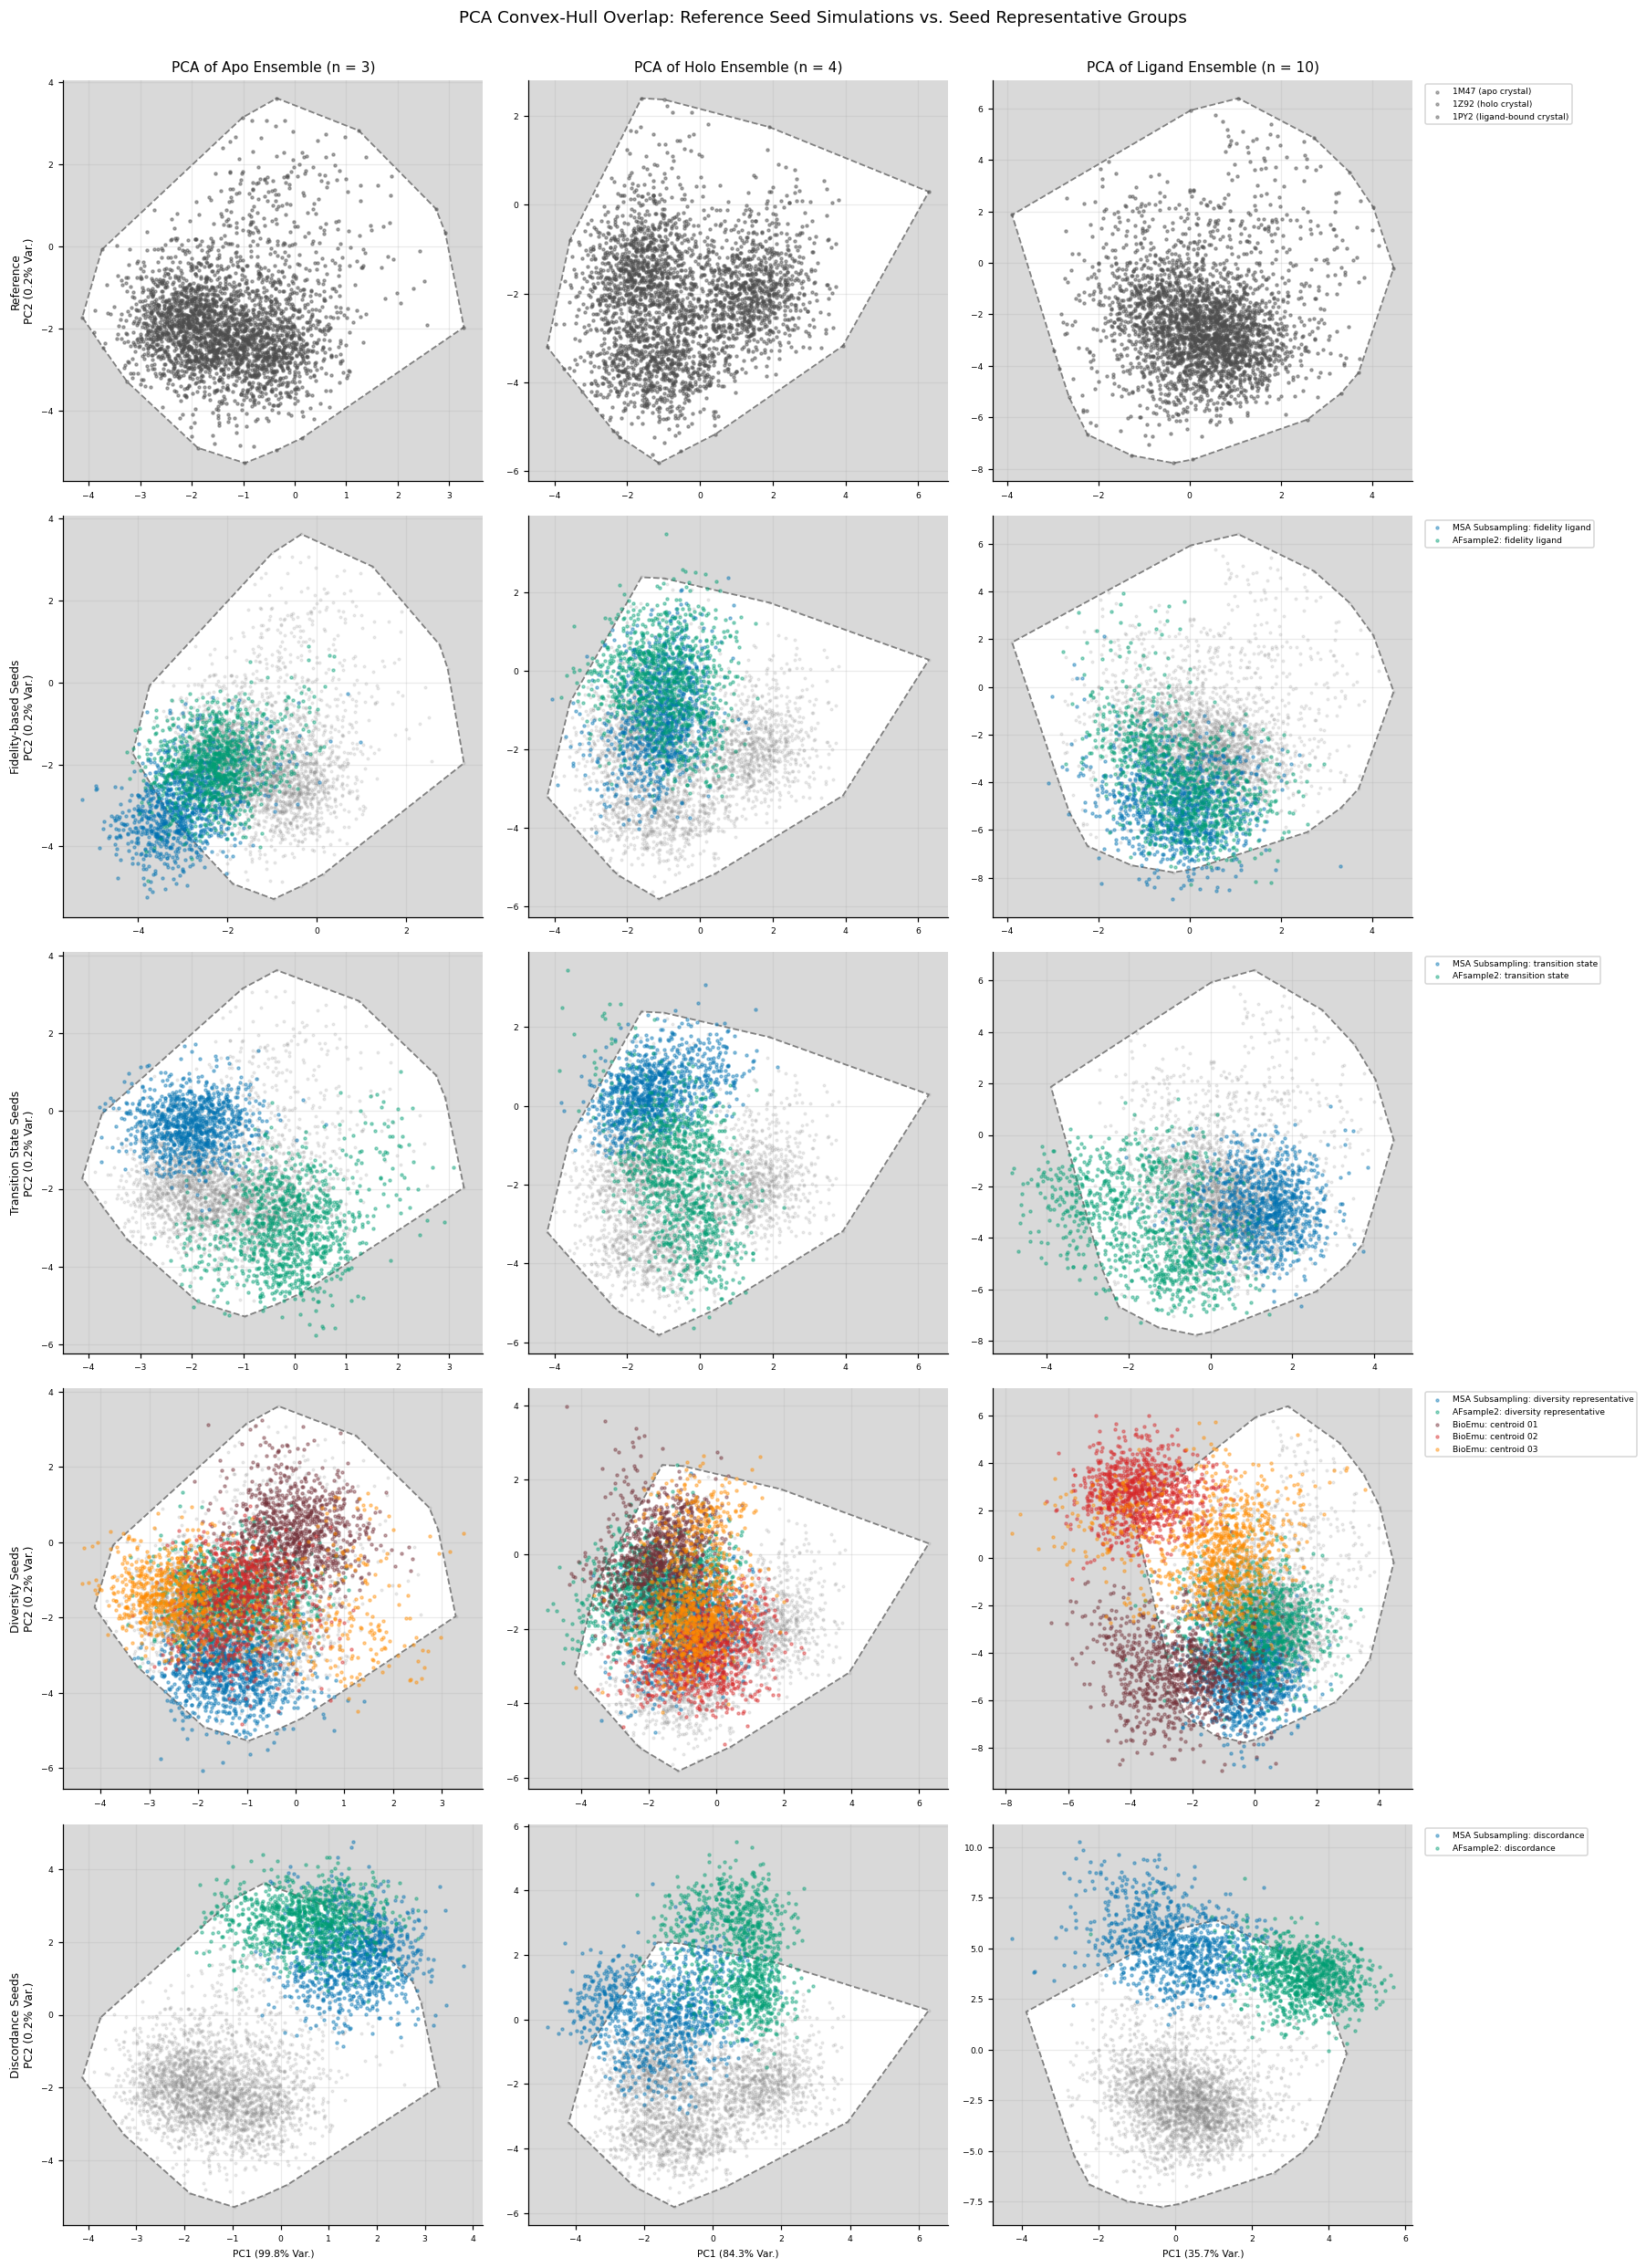

seed_group,pca_basis_state,system,model,criterion,n_frames,area_overlap_pct,n_frames_in_overlap_region,density_overlap_pct
Reference,apo,apo_1M47,Reference,crystal_apo,1001,100.00,1001,100.00
Reference,apo,receptor_1Z92,Reference,crystal_holo,1001,100.00,1001,100.00
Reference,apo,open_1PY2,Reference,crystal_ligand,1001,100.00,1001,100.00
Reference,holo,apo_1M47,Reference,crystal_apo,1001,100.00,1001,100.00
Reference,holo,receptor_1Z92,Reference,crystal_holo,1001,100.00,1001,100.00
Reference,holo,open_1PY2,Reference,crystal_ligand,1001,100.00,1001,100.00
Reference,ligand,apo_1M47,Reference,crystal_apo,1001,100.00,1001,100.00
Reference,ligand,receptor_1Z92,Reference,crystal_holo,1001,100.00,1001,100.00
Reference,ligand,open_1PY2,Reference,crystal_ligand,1001,100.00,1001,100.00
Fidelity-based Seeds,apo,ai_seeds_MSA_Subsampling_02_fidelity_ligand,MSA Subsampling,fidelity_ligand,1001,70.60,638,62.30


In [18]:
OVERLAP_TOLERANCE_PC = 0.25  # PCA-space units; a disclosed, stated choice (see markdown above)


def project_reference_pool_onto_basis(basis, replicas=(1, 2, 3)):
    """All available replicate frames of the three reference-seeded production systems,
    projected onto `basis` -- NOT just the static crystal landmark points."""
    all_scores = []
    for name in ("apo_1M47", "receptor_1Z92", "open_1PY2"):
        for replica in replicas:
            traj = get_traj(name, replica, REPLICA_PATHS)
            if traj is None:
                continue
            ca = ca_slice(traj)
            resolved = set(a.residue.resSeq for a in ca.topology.atoms)
            if not set(basis["resid_list"]).issubset(resolved):
                continue
            scores, _ = project_onto_pca(ca, basis)
            all_scores.append(scores)
    return np.concatenate(all_scores, axis=0) if all_scores else np.empty((0, 2))


def project_group_onto_basis(group, basis, replica=1):
    """This philosophy group's representative-seed frames (a single given replica), projected
    onto `basis`. Returns (combined_scores, [(system, model, n_frames), ...])."""
    all_scores, meta = [], []
    for sysdef in SYSTEMS:
        if sysdef["philosophy_group"] != group or sysdef["name"] not in AVAILABLE_SYSTEMS:
            continue
        traj = get_traj(sysdef["name"], replica, REPLICA_PATHS)
        if traj is None:
            continue
        ca = ca_slice(traj)
        resolved = set(a.residue.resSeq for a in ca.topology.atoms)
        if not set(basis["resid_list"]).issubset(resolved):
            continue
        scores, _ = project_onto_pca(ca, basis)
        all_scores.append(scores)
        meta.append((sysdef["name"], sysdef["model"], scores.shape[0]))
    combined = np.concatenate(all_scores, axis=0) if all_scores else np.empty((0, 2))
    return combined, meta


def _ccw(poly):
    """Reorder a convex polygon's vertices counter-clockwise if they aren't already --
    Sutherland-Hodgman requires consistent winding for its inside/outside edge test."""
    area2 = np.sum(poly[:, 0] * np.roll(poly[:, 1], -1) - np.roll(poly[:, 0], -1) * poly[:, 1])
    return poly if area2 > 0 else poly[::-1]


def _cross2(u, v):
    """Scalar (z-component) 2D cross product -- np.cross on plain 2D vectors is deprecated
    since NumPy 2.0, so this is spelled out explicitly rather than relying on that shim."""
    return u[0] * v[1] - u[1] * v[0]


def _convex_polygon_intersection(poly_a, poly_b):
    """Sutherland-Hodgman clip of poly_a against poly_b (both convex, (N,2) arrays) -> vertex
    array of the intersection polygon (CCW), or None if empty/degenerate. Exact for
    convex-vs-convex, which is all this notebook ever needs -- avoids a shapely dependency."""
    def inside(p, a, edge):
        return _cross2(edge, p - a) >= -1e-12

    def line_intersect(p1, p2, p3, p4):
        d1, d2 = p2 - p1, p4 - p3
        denom = _cross2(d1, d2)
        if abs(denom) < 1e-12:
            return p2
        t = _cross2(p3 - p1, d2) / denom
        return p1 + t * d1

    output = list(_ccw(np.asarray(poly_a, dtype=float)))
    clip_poly = _ccw(np.asarray(poly_b, dtype=float))
    n = len(clip_poly)
    for i in range(n):
        if not output:
            return None
        input_list, output = output, []
        a, b = clip_poly[i], clip_poly[(i + 1) % n]
        edge = b - a
        for j in range(len(input_list)):
            cur, prev = input_list[j], input_list[j - 1]
            cur_in, prev_in = inside(cur, a, edge), inside(prev, a, edge)
            if cur_in:
                if not prev_in:
                    output.append(line_intersect(prev, cur, a, b))
                output.append(cur)
            elif prev_in:
                output.append(line_intersect(prev, cur, a, b))
    return np.array(output) if len(output) >= 3 else None


def _polygon_area(poly):
    x, y = poly[:, 0], poly[:, 1]
    return 0.5 * abs(np.sum(x * np.roll(y, -1) - np.roll(x, -1) * y))


def _points_in_convex_polygon(points, poly):
    poly = _ccw(np.asarray(poly, dtype=float))
    points = np.asarray(points, dtype=float)
    mask = np.ones(len(points), dtype=bool)
    n = len(poly)
    for i in range(n):
        a, b = poly[i], poly[(i + 1) % n]
        edge = b - a
        cross = edge[0] * (points[:, 1] - a[1]) - edge[1] * (points[:, 0] - a[0])
        mask &= cross >= -1e-9
    return mask


def hull_area_and_density_overlap(seed_scores, ref_scores, tol=OVERLAP_TOLERANCE_PC):
    """Area Overlap and Density Overlap (see markdown above for definitions) between one
    seed's own projected frames and the pooled reference-simulation frames. Returns
    (area_overlap_pct, density_overlap_pct, n_frames_in_overlap_region); NaN/0 if either hull
    can't be built (fewer than 3 non-collinear points)."""
    if len(seed_scores) < 3 or len(ref_scores) < 3:
        return np.nan, np.nan, 0
    try:
        seed_hull, ref_hull = ConvexHull(seed_scores), ConvexHull(ref_scores)
    except Exception:
        return np.nan, np.nan, 0

    seed_poly = seed_scores[seed_hull.vertices]
    ref_poly = ref_scores[ref_hull.vertices]
    seed_area = _polygon_area(_ccw(seed_poly))
    if seed_area == 0:
        return np.nan, np.nan, 0

    clipped = _convex_polygon_intersection(seed_poly, ref_poly)
    if clipped is None:
        return 0.0, 0.0, 0

    area_overlap_pct = 100 * _polygon_area(clipped) / seed_area
    in_overlap_mask = _points_in_convex_polygon(seed_scores, clipped)
    n_in_overlap = int(in_overlap_mask.sum())
    if n_in_overlap == 0:
        return area_overlap_pct, 0.0, 0

    tree = cKDTree(ref_scores)
    dist, _ = tree.query(seed_scores[in_overlap_mask])
    n_qualifying = int((dist <= tol).sum())
    density_overlap_pct = 100 * n_qualifying / len(seed_scores)
    return area_overlap_pct, density_overlap_pct, n_in_overlap


PCA_BASIS_STATES = ["apo", "holo", "ligand"]
ref_scores_cache = {state: project_reference_pool_onto_basis(pca_basis[state], replicas=(1,))
                     for state in PCA_BASIS_STATES}
for _state, _scores in ref_scores_cache.items():
    print(f"Replicate-1 reference-simulation frames projected onto {_state} basis: {len(_scores)}")


def system_plot_title(name, model):
    sysdef = SYSTEM_BY_NAME[name]
    return sysdef.get("label") or f"{model}: {sysdef['criterion'].replace('_', ' ')}"


def plot_hull_overlap_grid(states, group_order, ncols_scale=5.5, nrows_scale=4.5,
                            title="", fname="pca_hull_overlap_grid"):
    """Shared PCA-hull plotting routine: one row per seed group, one column per PCA basis
    state. Used both for the full 3-state grid and the apo-only summary panel below."""
    rows = []
    fig, axes = plt.subplots(len(group_order), len(states),
                              figsize=(ncols_scale * len(states), nrows_scale * len(group_order)),
                              squeeze=False)
    for _ri, _group in enumerate(group_order):
        for _ci, _state in enumerate(states):
            ax = axes[_ri, _ci]
            _basis = pca_basis[_state]
            _ref_scores = ref_scores_cache[_state]
            _group_scores, _meta = project_group_onto_basis(_group, _basis, replica=1)

            ax.set_facecolor("#d9d9d9")
            if len(_ref_scores) >= 3:
                _hull = ConvexHull(_ref_scores)
                _hull_pts = np.vstack([_ref_scores[_hull.vertices], _ref_scores[_hull.vertices[:1]]])
                ax.add_patch(MplHullPatch(_ref_scores[_hull.vertices], closed=True, facecolor="white",
                                            edgecolor="none", zorder=0.5))
                ax.plot(_hull_pts[:, 0], _hull_pts[:, 1], color="grey", linestyle="--", linewidth=1.2, zorder=3)
            ax.scatter(_ref_scores[:, 0], _ref_scores[:, 1], s=3, alpha=0.15, color="grey", zorder=2,
                       label="_nolegend_")

            if len(_group_scores) > 0:
                _offset, _seen = 0, set()
                for _name, _model, _n in _meta:
                    _seg = _group_scores[_offset:_offset + _n]
                    _color = BIOEMU_CENTROID_COLORS.get(_name, MODEL_COLORS.get(_model, "#333"))
                    _title = system_plot_title(_name, _model)
                    ax.scatter(_seg[:, 0], _seg[:, 1], s=4, alpha=0.4, color=_color,
                               zorder=4, label=(_title if _name not in _seen else "_nolegend_"))
                    if _name not in _seen:
                        _area_ov, _density_ov, _n_in_ov = hull_area_and_density_overlap(_seg, _ref_scores)
                        rows.append(dict(
                            seed_group=_group, pca_basis_state=_state, system=_name, model=_model,
                            criterion=SYSTEM_BY_NAME[_name]["criterion"], n_frames=_n,
                            area_overlap_pct=round(_area_ov, 1) if pd.notna(_area_ov) else np.nan,
                            n_frames_in_overlap_region=_n_in_ov,
                            density_overlap_pct=round(_density_ov, 1) if pd.notna(_density_ov) else np.nan))
                    _seen.add(_name)
                    _offset += _n
            else:
                ax.text(0.5, 0.5, "no data", transform=ax.transAxes, ha="center", va="center", fontsize=8)

            if _basis["pca"] is not None:
                _pc1_pct, _pc2_pct = _basis["pca"].explained_variance_ratio_[:2] * 100
            else:
                _pc1_pct, _pc2_pct = float("nan"), float("nan")
            if _ri == 0:
                ax.set_title(f"PCA of {STATE_DISPLAY[_state]} Ensemble (n = {_basis['ref_traj'].n_frames})",
                             fontsize=10)
            if _ci == 0:
                ax.set_ylabel(f"{_group}\nPC2 ({_pc2_pct:.1f}% Var.)", fontsize=8)
            if _ri == len(group_order) - 1:
                ax.set_xlabel(f"PC1 ({_pc1_pct:.1f}% Var.)", fontsize=7)
            ax.tick_params(labelsize=6)
            if _ci == len(states) - 1:
                _handles, _labels = ax.get_legend_handles_labels()
                _uniq = dict(zip(_labels, _handles))
                ax.legend(_uniq.values(), _uniq.keys(), fontsize=6, loc="upper left", bbox_to_anchor=(1.02, 1.0))
    fig.suptitle(title, y=1.002, fontsize=12)
    plt.tight_layout()
    plt.savefig(f"{FIGURES_DIR}/{fname}.png", dpi=150, bbox_inches="tight")
    plt.show()
    return pd.DataFrame(rows)


hull_overlap_df = plot_hull_overlap_grid(
    PCA_BASIS_STATES, GROUP_ORDER,
    title="PCA Convex-Hull Overlap: Reference Seed Simulations vs. Seed Representative Groups",
    fname="pca_hull_overlap_grid")
display_table(hull_overlap_df, caption="Per-representative-seed area/density overlap (replicate 1)")

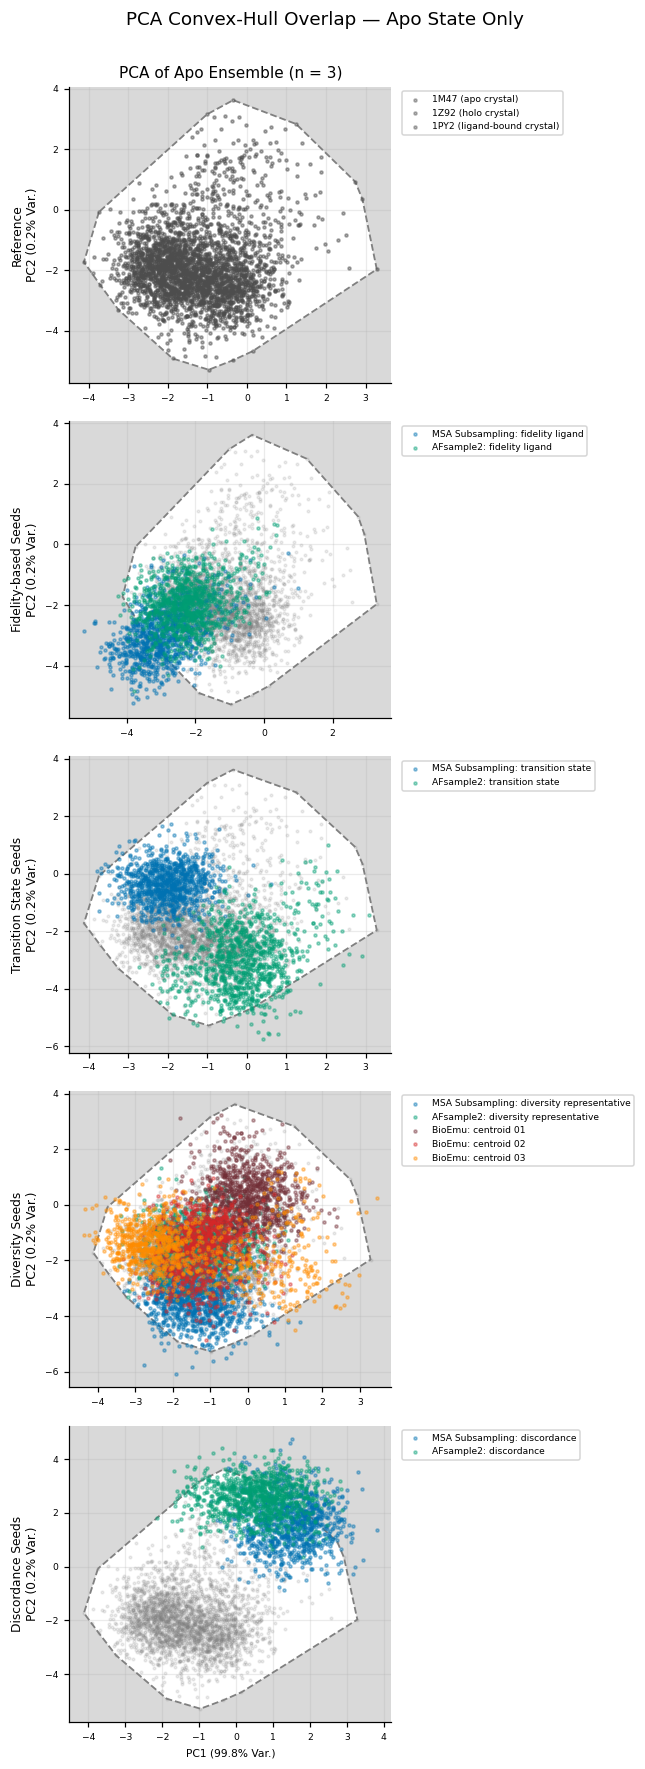

seed_group,pca_basis_state,n_representatives,area_overlap_pct_mean,density_overlap_pct_mean
Discordance Seeds,apo,2,57.85,57.10
Discordance Seeds,holo,2,53.90,49.00
Discordance Seeds,ligand,2,42.75,29.00
Diversity Seeds,apo,5,93.30,96.60
Diversity Seeds,holo,5,86.08,95.44
Diversity Seeds,ligand,5,64.16,64.02
Fidelity-based Seeds,apo,2,78.45,79.60
Fidelity-based Seeds,holo,2,90.20,95.60
Fidelity-based Seeds,ligand,2,88.75,90.65
Reference,apo,3,100.00,100.00


In [19]:
hull_overlap_apo_df = plot_hull_overlap_grid(
    ["apo"], GROUP_ORDER, ncols_scale=6.0, nrows_scale=3.2,
    title="PCA Convex-Hull Overlap — Apo State Only", fname="pca_hull_overlap_apo_only")

# Group-level summary: mean of each representative's own area/density overlap within that group.
hull_overlap_group_df = hull_overlap_df.groupby(["seed_group", "pca_basis_state"]).agg(
    n_representatives=("system", "nunique"),
    area_overlap_pct_mean=("area_overlap_pct", "mean"),
    density_overlap_pct_mean=("density_overlap_pct", "mean"),
).reset_index()
display_table(hull_overlap_group_df, caption="Group-level mean area/density overlap by PCA basis state")

**Reproducibility.** Recompute area/density overlap per replicate (1–3) for each (system, PCA basis) and each (seed group, PCA basis) combination — the pooled reference hull itself already pools all 3 reference systems' replicates and is unchanged across replicates; only the seed/group's own projected frames vary. Ranked on `density_overlap_pct`, the stricter, occupancy-aware of the two metrics.

In [20]:
def hull_overlap_replicate_reproducibility(per_system=True):
    """Shared reproducibility routine for individual representative seeds (per_system=True) or
    pooled seed groups (per_system=False) -- identical logic, only the unit of projection differs
    (a single system's own frames vs. a group's pooled frames)."""
    rows = []
    if per_system:
        for _sysdef in SYSTEMS:
            _name = _sysdef["name"]
            if _name not in AVAILABLE_SYSTEMS:
                continue
            for _state in PCA_BASIS_STATES:
                _basis, _ref_scores = pca_basis[_state], ref_scores_cache[_state]
                for _replica in (1, 2, 3):
                    _traj = get_traj(_name, _replica, REPLICA_PATHS)
                    if _traj is None:
                        continue
                    _ca = ca_slice(_traj)
                    _resolved = set(a.residue.resSeq for a in _ca.topology.atoms)
                    if not set(_basis["resid_list"]).issubset(_resolved):
                        continue
                    _scores, _ = project_onto_pca(_ca, _basis)
                    _area_ov, _density_ov, _ = hull_area_and_density_overlap(_scores, _ref_scores)
                    rows.append(dict(unit=_name, model=_sysdef["model"], criterion=_sysdef["criterion"],
                                      seed_group=_sysdef["philosophy_group"], pca_basis_state=_state,
                                      replica=_replica, area_overlap_pct=_area_ov, density_overlap_pct=_density_ov))
    else:
        for _group in GROUP_ORDER:
            for _state in PCA_BASIS_STATES:
                _ref_scores = ref_scores_cache[_state]
                for _replica in (1, 2, 3):
                    _group_scores, _ = project_group_onto_basis(_group, pca_basis[_state], replica=_replica)
                    if len(_group_scores) == 0:
                        continue
                    _area_ov, _density_ov, _ = hull_area_and_density_overlap(_group_scores, _ref_scores)
                    rows.append(dict(unit=_group, seed_group=_group, pca_basis_state=_state,
                                      replica=_replica, area_overlap_pct=_area_ov, density_overlap_pct=_density_ov))

    replicate_df = pd.DataFrame(rows)
    summary_rows = []
    for (_unit, _state), _g in replicate_df.groupby(["unit", "pca_basis_state"]):
        _row = dict(unit=_unit, seed_group=_g["seed_group"].iloc[0], pca_basis_state=_state,
                    n_replicates=len(_g))
        if per_system:
            _row["model"] = _g["model"].iloc[0]
            _row["criterion"] = _g["criterion"].iloc[0]
        for _metric in ["area_overlap_pct", "density_overlap_pct"]:
            _row[f"{_metric}_mean"] = round(float(_g[_metric].mean()), 1)
            _row[f"{_metric}_sd"] = round(float(_g[_metric].std()), 1) if len(_g) > 1 else np.nan
        summary_rows.append(_row)
    summary_df = pd.DataFrame(summary_rows)
    summary_df["spread_rank"] = tukey_iqr_spread_rank(summary_df, "density_overlap_pct_sd")
    return summary_df


seed_hull_overlap_reproducibility_df = hull_overlap_replicate_reproducibility(per_system=True)
display_table(seed_hull_overlap_reproducibility_df.sort_values("spread_rank"),
              caption="Per-representative-seed PCA hull-overlap reproducibility, ranked most (1) to least reproducible")

unit,seed_group,pca_basis_state,n_replicates,model,criterion,area_overlap_pct_mean,area_overlap_pct_sd,density_overlap_pct_mean,density_overlap_pct_sd,spread_rank
ai_seeds_MSA_Subsampling_03_transition_state,Transition State Seeds,ligand,3,MSA Subsampling,transition_state,99.80,0.40,98.70,0.70,1
ai_seeds_MSA_Subsampling_03_transition_state,Transition State Seeds,apo,3,MSA Subsampling,transition_state,97.90,1.80,98.70,1.20,2
ai_seeds_MSA_Subsampling_04_diversity_representative,Diversity Seeds,apo,3,MSA Subsampling,diversity_representative,87.00,8.70,96.90,1.90,3
ai_seeds_AFsample2_04_diversity_representative,Diversity Seeds,apo,3,AFsample2,diversity_representative,95.00,5.80,97.60,2.70,4
ai_seeds_AFsample2_03_transition_state,Transition State Seeds,holo,3,AFsample2,transition_state,83.90,7.00,95.30,3.00,5
ai_seeds_AFsample2_02_fidelity_ligand,Fidelity-based Seeds,apo,3,AFsample2,fidelity_ligand,87.60,4.10,96.10,3.40,6
ai_seeds_AFsample2_02_fidelity_ligand,Fidelity-based Seeds,holo,3,AFsample2,fidelity_ligand,81.80,3.00,91.80,3.40,7
open_1PY2,Reference,holo,3,Reference,crystal_ligand,95.40,7.90,97.90,3.60,8
receptor_1Z92,Reference,apo,3,Reference,crystal_holo,95.70,7.30,96.60,3.70,9
ai_seeds_BioEmu_01_centroid_01,Diversity Seeds,holo,3,BioEmu,centroid_01,77.70,17.90,93.30,3.90,10


In [21]:
# Defined here (moved earlier from its original later use) so the new reproducibility bar-chart
# cells below can use it -- same list as originally defined further down in this notebook.
MODEL_ORDER = ["Reference", "MSA Subsampling", "AFsample2", "BioEmu"]

In [22]:
def hull_overlap_system_reproducibility():
    """Same per-replica area/density overlap rows as hull_overlap_replicate_reproducibility's
    per_system branch, but averaged per system pooling across BOTH replicates and PCA basis
    states -- one row per system, rather than one row per (system, state)."""
    rows = []
    for _sysdef in SYSTEMS:
        _name = _sysdef["name"]
        if _name not in AVAILABLE_SYSTEMS:
            continue
        for _state in PCA_BASIS_STATES:
            _basis, _ref_scores = pca_basis[_state], ref_scores_cache[_state]
            for _replica in (1, 2, 3):
                _traj = get_traj(_name, _replica, REPLICA_PATHS)
                if _traj is None:
                    continue
                _ca = ca_slice(_traj)
                _resolved = set(a.residue.resSeq for a in _ca.topology.atoms)
                if not set(_basis["resid_list"]).issubset(_resolved):
                    continue
                _scores, _ = project_onto_pca(_ca, _basis)
                _area_ov, _density_ov, _ = hull_area_and_density_overlap(_scores, _ref_scores)
                rows.append(dict(unit=_name, model=_sysdef["model"], criterion=_sysdef["criterion"],
                                  seed_group=_sysdef["philosophy_group"], pca_basis_state=_state,
                                  replica=_replica, area_overlap_pct=_area_ov, density_overlap_pct=_density_ov))

    replicate_df = pd.DataFrame(rows)
    summary_rows = []
    for _unit, _g in replicate_df.groupby("unit"):
        _row = dict(unit=_unit, seed_group=_g["seed_group"].iloc[0], model=_g["model"].iloc[0],
                    criterion=_g["criterion"].iloc[0], n_samples=len(_g))
        for _metric in ["area_overlap_pct", "density_overlap_pct"]:
            _row[f"{_metric}_mean"] = round(float(_g[_metric].mean()), 1)
            _row[f"{_metric}_sd"] = round(float(_g[_metric].std()), 1) if len(_g) > 1 else np.nan
        summary_rows.append(_row)
    summary_df = pd.DataFrame(summary_rows)
    summary_df["spread_rank"] = tukey_iqr_spread_rank(summary_df, "density_overlap_pct_sd")
    return summary_df


seed_hull_overlap_system_reproducibility_df = hull_overlap_system_reproducibility()
display_table(seed_hull_overlap_system_reproducibility_df.sort_values("spread_rank"),
              caption="Per-system PCA hull-overlap reproducibility, averaged across replicates and "
                      "PCA basis states, ranked most (1) to least reproducible")


unit,seed_group,model,criterion,n_samples,area_overlap_pct_mean,area_overlap_pct_sd,density_overlap_pct_mean,density_overlap_pct_sd,spread_rank
ai_seeds_AFsample2_02_fidelity_ligand,Fidelity-based Seeds,AFsample2,fidelity_ligand,9,86.50,7.60,93.40,4.50,1
ai_seeds_AFsample2_04_diversity_representative,Diversity Seeds,AFsample2,diversity_representative,9,89.60,10.30,93.90,7.30,2
open_1PY2,Reference,Reference,crystal_ligand,9,93.10,10.00,93.00,12.60,3
ai_seeds_MSA_Subsampling_02_fidelity_ligand,Fidelity-based Seeds,MSA Subsampling,fidelity_ligand,9,84.70,13.20,88.30,13.40,4
ai_seeds_MSA_Subsampling_03_transition_state,Transition State Seeds,MSA Subsampling,transition_state,9,90.90,16.70,92.60,13.90,5
receptor_1Z92,Reference,Reference,crystal_holo,9,89.90,11.30,89.80,14.60,6
apo_1M47,Reference,Reference,crystal_apo,9,84.20,16.70,86.50,15.70,7
ai_seeds_MSA_Subsampling_04_diversity_representative,Diversity Seeds,MSA Subsampling,diversity_representative,9,86.60,10.30,88.60,19.20,8
ai_seeds_BioEmu_03_centroid_03,Diversity Seeds,BioEmu,centroid_03,9,69.80,17.70,68.60,23.30,9
ai_seeds_AFsample2_03_transition_state,Transition State Seeds,AFsample2,transition_state,9,77.80,22.30,80.30,24.90,10


In [23]:
group_hull_overlap_reproducibility_df = hull_overlap_replicate_reproducibility(per_system=False)
display_table(group_hull_overlap_reproducibility_df.sort_values("spread_rank"),
              caption="Group-level PCA hull-overlap reproducibility, ranked most (1) to least reproducible")

unit,seed_group,pca_basis_state,n_replicates,area_overlap_pct_mean,area_overlap_pct_sd,density_overlap_pct_mean,density_overlap_pct_sd,spread_rank
Fidelity-based Seeds,Fidelity-based Seeds,ligand,3,84.00,2.20,90.50,1.10,1
Transition State Seeds,Transition State Seeds,apo,3,94.80,4.90,96.00,2.70,2
Diversity Seeds,Diversity Seeds,holo,3,70.60,1.70,92.00,3.00,3
Reference,Reference,apo,3,85.10,13.70,93.70,7.00,4
Diversity Seeds,Diversity Seeds,ligand,3,46.00,8.50,56.30,8.40,5
Fidelity-based Seeds,Fidelity-based Seeds,holo,3,77.30,8.40,90.80,8.70,6
Reference,Reference,holo,3,84.40,13.90,89.80,9.80,7
Fidelity-based Seeds,Fidelity-based Seeds,apo,3,82.80,7.10,91.30,10.20,8
Transition State Seeds,Transition State Seeds,holo,3,78.20,14.60,87.80,11.90,9
Transition State Seeds,Transition State Seeds,ligand,3,71.20,13.50,75.50,12.90,10


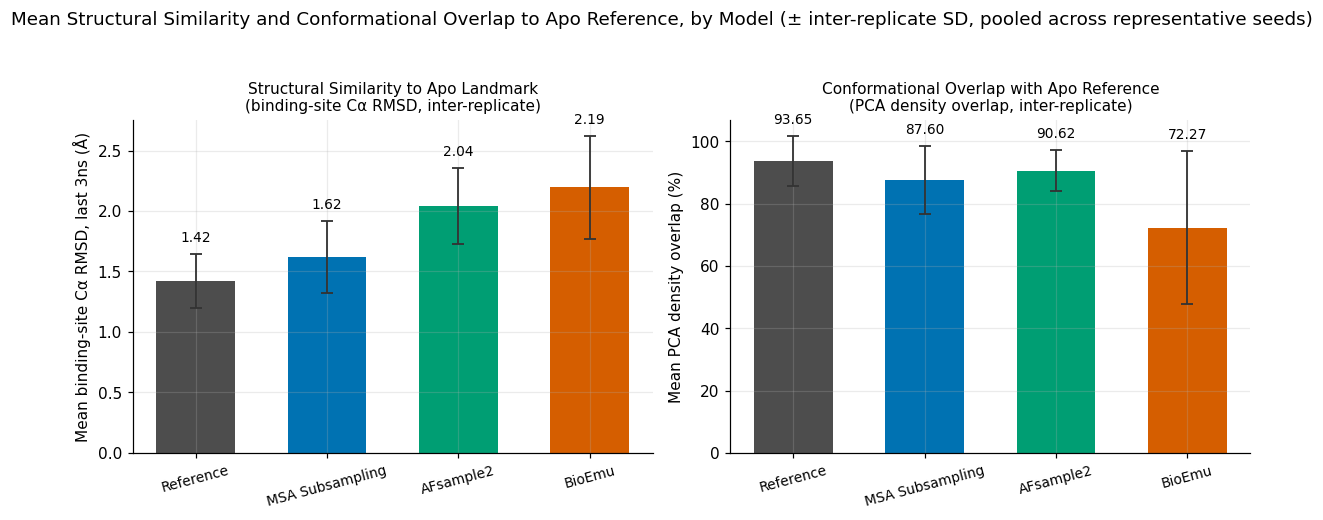

In [24]:
def per_replica_late_window_apo(rmsd_fn, systems, replica_paths, late_window_ns=LATE_WINDOW_NS):
    """Per-(system, replica) late-window plateau RMSD (apo landmark only, states_to_try=["apo"]
    regardless of a system's own natural state) -- one row per replica."""
    rows = []
    for name in systems:
        sysdef = SYSTEM_BY_NAME[name]
        paths = replica_paths.get(name, {})
        for replica in (1, 2, 3):
            if replica not in paths:
                continue
            traj = get_traj(name, replica, replica_paths)
            ca = ca_slice(traj)
            rmsd, _, _ = rmsd_fn(ca, ["apo"])
            time_ns = traj.time / 1000.0
            late_mask = time_ns >= (time_ns.max() - late_window_ns)
            rows.append(dict(system=name, model=sysdef["model"], replica=replica,
                              plateau_rmsd=float(rmsd[late_mask].mean())))
    return pd.DataFrame(rows)


def mean_and_interreplicate_sd(per_replica_df, value_col):
    """From per-(system, replica) rows: each representative system's own inter-replicate
    mean/SD first (across just its own up-to-3 replicates), then averaged across a model's
    representative systems -- so a system with an unusually different average value doesn't
    leak into the "inter-replicate" SD."""
    per_system = per_replica_df.groupby(["system", "model"])[value_col].agg(["mean", "std"])
    return per_system.groupby("model").agg(
        n_representatives=("mean", "size"), value_mean=("mean", "mean"), value_sd=("std", "mean"),
    ).reindex(MODEL_ORDER).reset_index()


rmsd_per_replica_apo_df = per_replica_late_window_apo(
    lambda ca, states: rmsd_series_vs_landmarks(ca, states, binding_site_only=True),
    PRIORITIZED_REPLICATE_SYSTEMS, REPLICA_PATHS)
structural_similarity_model_df = mean_and_interreplicate_sd(rmsd_per_replica_apo_df, "plateau_rmsd")


def per_replica_density_overlap_apo():
    """Per-(system, replica) PCA density overlap against the apo basis."""
    basis, ref_scores = pca_basis["apo"], ref_scores_cache["apo"]
    rows = []
    for sysdef in SYSTEMS:
        name = sysdef["name"]
        if name not in AVAILABLE_SYSTEMS:
            continue
        for replica in (1, 2, 3):
            traj = get_traj(name, replica, REPLICA_PATHS)
            if traj is None:
                continue
            ca = ca_slice(traj)
            resolved = set(a.residue.resSeq for a in ca.topology.atoms)
            if not set(basis["resid_list"]).issubset(resolved):
                continue
            scores, _ = project_onto_pca(ca, basis)
            _, density_ov, _ = hull_area_and_density_overlap(scores, ref_scores)
            rows.append(dict(system=name, model=sysdef["model"], replica=replica,
                              density_overlap_pct=density_ov))
    return pd.DataFrame(rows)


density_overlap_per_replica_apo_df = per_replica_density_overlap_apo()
conformational_overlap_model_df = mean_and_interreplicate_sd(
    density_overlap_per_replica_apo_df, "density_overlap_pct")

# --- Plot: two bar charts, one per metric, apo state only ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, df, ylabel, title in [
    (ax1, structural_similarity_model_df, "Mean binding-site Cα RMSD, last 3ns (Å)",
     "Structural Similarity to Apo Landmark\n(binding-site Cα RMSD, inter-replicate)"),
    (ax2, conformational_overlap_model_df, "Mean PCA density overlap (%)",
     "Conformational Overlap with Apo Reference\n(PCA density overlap, inter-replicate)"),
]:
    x = np.arange(len(df))
    colors = [MODEL_COLORS[m] for m in df["model"]]
    ax.bar(x, df["value_mean"], width=0.6, color=colors, edgecolor="none",
           yerr=df["value_sd"], capsize=4,
           error_kw=dict(ecolor="#333333", elinewidth=1.2, capthick=1.2))
    _ymax = (df["value_mean"] + df["value_sd"].fillna(0)).max()
    for xi, row in zip(x, df.itertuples()):
        _sd = 0.0 if np.isnan(row.value_sd) else row.value_sd
        ax.text(xi, row.value_mean + _sd + 0.03 * _ymax,
                f"{row.value_mean:.2f}", ha="center", va="bottom", fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels(df["model"], fontsize=9, rotation=15)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=10)

fig.suptitle("Mean Structural Similarity and Conformational Overlap to Apo Reference, "
             "by Model (± inter-replicate SD, pooled across representative seeds)", y=1.04)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/reproducibility_by_model_apo.png", dpi=150, bbox_inches="tight")
plt.show()


**Interpretation.** Density overlap against the ligand basis falls in the rank order predicted by selection philosophy — fidelity-based seeds highest, followed by transition-state, diversity, then discordance seeds lowest — while the apo and holo bases are far less discriminating between groups, since the three IL-2 states differ locally at the binding site rather than globally across the backbone (Section 4.2). A seed can still occupy the reference ensemble's broad collective-motion subspace on the apo/holo basis while remaining locally displaced from any single landmark under binding-site RMSD (Section 4.2) — the two analyses are complementary, not redundant.

Reproducibility follows the identical architectural split established under RMSD (Section 4): fidelity-ligand seeds are the most reproducible cells in the table, since a structure anchored to one dominant fold moves through a small, predictable patch of the collective-motion subspace regardless of replicate. Diversity seeds split by model again — MSA Subsampling and AFsample2's diversity representatives remain perturbations of the same single-answer network, so even when they land outside the reference basin, they land somewhere *consistent* across replicates. BioEmu has no equivalent anchor: replicates from the same centroid can relax into different, only partly overlapping regions of the subspace. The mechanism is architectural rather than data-driven — perturbing a discriminative single-answer network keeps outputs anchored even when diversified; sampling a generative equilibrium model carries no such anchor, and reproducibility is the first thing lost once the seed is asked to move away from the model's single most confident state.

## 7. Landmark-Specific State Recovery

Reuses `REF_STATE_CHAIN` and `rmsd_to_landmark` (Section 4) to classify frames against the three exact structures used to seed MD production, rather than the pooled reference library.

For every available system/replicate, three independent, non-exclusive per-frame masks (`apo_like`, `holo_like`, `ligand_like`) are evaluated against the single landmark structures — a frame may satisfy zero, one, two, or all three. A fourth, derived mask (`questionable_relevance`) flags frames satisfying none of the three.

**What "questionable biological relevance" does and does not mean.** A frame in this category has **not failed** to be biologically meaningful — it has simply not met the specific threshold-based definition used for any of the three named states here. This can happen for several genuinely different reasons this single category cannot distinguish between: a frame narrowly missing one criterion (e.g. binding-site RMSD at 2.1 Å against a 2.0 Å cutoff), a genuine transitional conformation between two states (consistent with the Phe42 χ1 fluctuation behaviour described in the thesis literature review), or a frame that has moved into conformational space not represented by any of the three reference states at all. The occupancy fraction below is reported for transparency and as a sanity check on how much of each trajectory the three-state framework accounts for — **not** as a claim that these frames are irrelevant.

In [25]:
def compute_state_recovery_masks(traj):
    """Three independent, non-exclusive per-frame boolean masks (apo_like, holo_like,
    ligand_like) against SINGLE landmark structures (rmsd_to_landmark, Section 4) -- distinct
    from the pooled-reference metrics used elsewhere. Returns None if required residues are not
    fully resolved in this trajectory."""
    ca = ca_slice(traj)
    resolved = set(a.residue.resSeq for a in traj.topology.atoms)
    if not set(POCKET_LINING_RESIDUES).issubset(resolved):
        return None

    apo_like = (rmsd_to_landmark(ca, "apo") < 2.0) & (rmsd_to_landmark(ca, "apo", binding_site_only=True) < 2.0)
    holo_like = (rmsd_to_landmark(ca, "holo") < 2.0) & (rmsd_to_landmark(ca, "holo", binding_site_only=True) < 2.0)

    rmsd_ligand_whole = rmsd_to_landmark(ca, "ligand")
    rmsd_ligand_bs = rmsd_to_landmark(ca, "ligand", binding_site_only=True)
    chi1 = chi1_for_gating_residues(traj, residues={42: "PHE"})
    if 42 not in chi1:
        return None
    chi1_open = angular_diff(chi1[42], REF_CHI1[42]) <= 60.0
    vol = pocket_hull_volume_series_A3(traj, POCKET_LINING_RESIDUES)
    vol_in_range = (vol >= POCKET_RECOVERY_MIN_A3) & (vol <= POCKET_RECOVERY_MAX_A3)
    ligand_like = (rmsd_ligand_whole < 2.0) & (rmsd_ligand_bs < 2.0) & chi1_open & vol_in_range

    questionable_relevance = ~(apo_like | holo_like | ligand_like)
    return dict(apo=apo_like, holo=holo_like, ligand=ligand_like,
                questionable_relevance=questionable_relevance)


state_recovery_rows = []
for _name in PRIORITIZED_REPLICATE_SYSTEMS:
    _sysdef = SYSTEM_BY_NAME[_name]
    _paths = REPLICA_PATHS.get(_name, {})
    if not _paths:
        continue
    for _replica in (1, 2, 3):
        if _replica not in _paths:
            continue
        _traj = get_traj(_name, _replica, REPLICA_PATHS)
        _masks = compute_state_recovery_masks(_traj)
        if _masks is None:
            print(f"  {_name} replica {_replica}: SKIPPED (required residues not resolved)")
            continue
        for _state, _mask in _masks.items():
            state_recovery_rows.append(dict(
                system=_name, model=_sysdef["model"], criterion=_sysdef["criterion"],
                philosophy_group=_sysdef["philosophy_group"], replica=_replica,
                state=_state, occupancy_pct=round(float(_mask.mean() * 100), 2)))

state_recovery_df = pd.DataFrame(state_recovery_rows)
print(f"{len(state_recovery_df)} rows ({state_recovery_df.system.nunique()} systems x up to 3 "
      f"replicas x 4 states).")

MODEL_ORDER = ["Reference", "MSA Subsampling", "AFsample2", "BioEmu"]
STATE_RECOVERY_LABELS = {"apo": "Apo-like", "holo": "Holo-like", "ligand": "Ligand-like",
                          "questionable_relevance": "Questionable biological relevance"}

168 rows (14 systems x up to 3 replicas x 4 states).


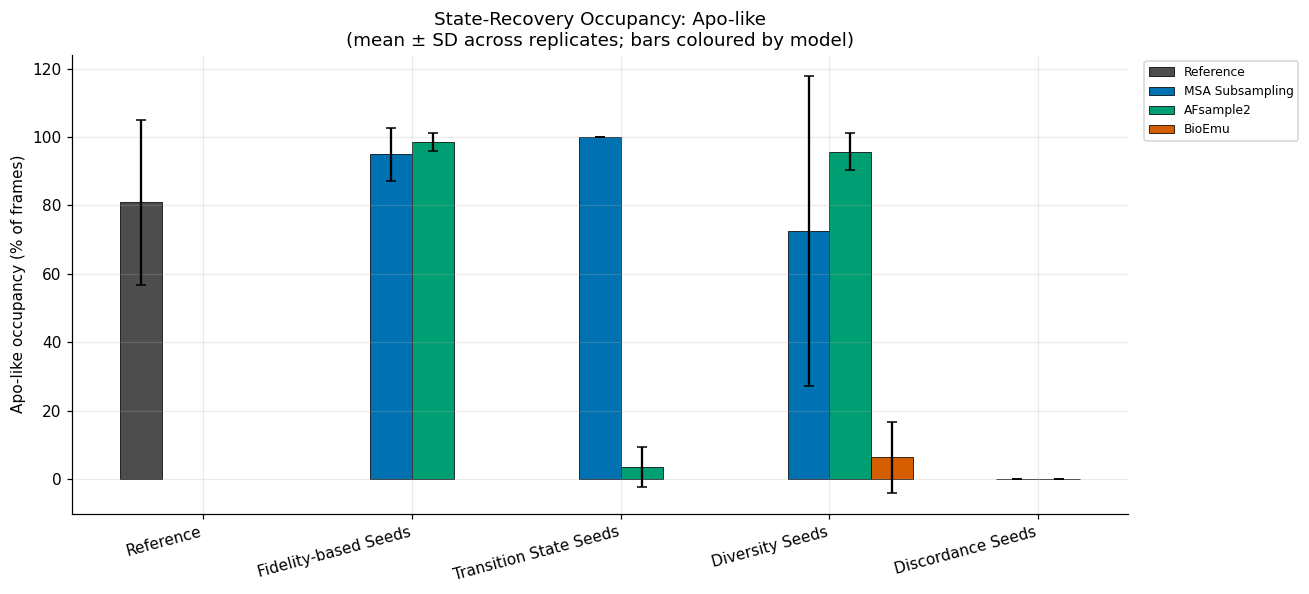

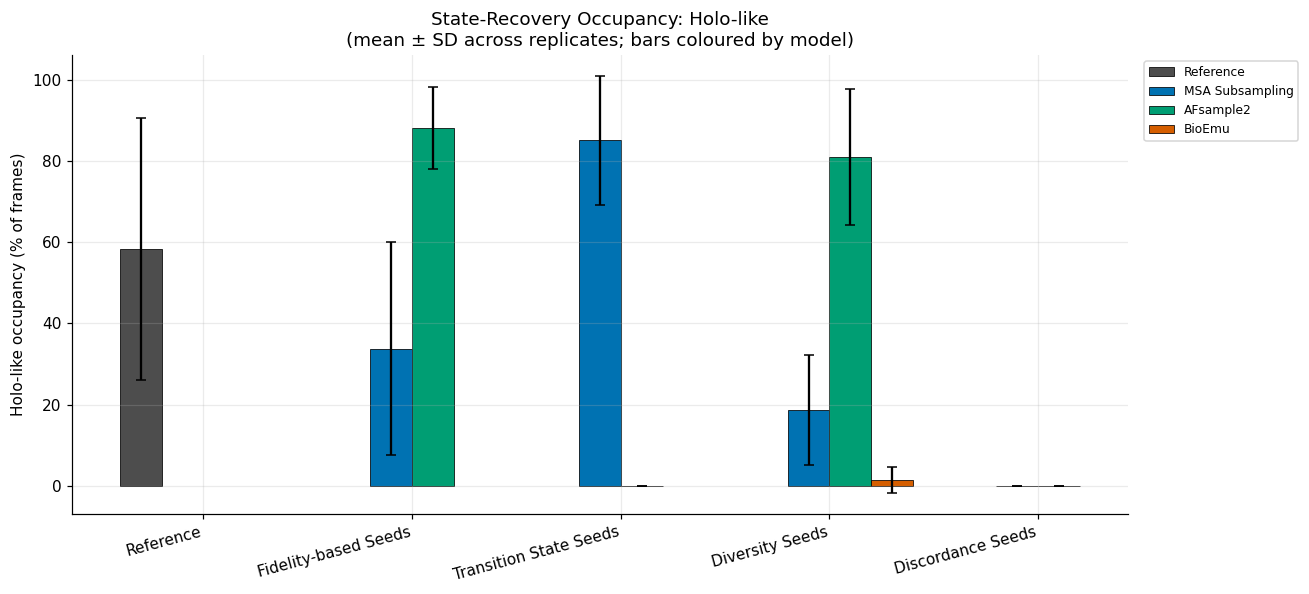

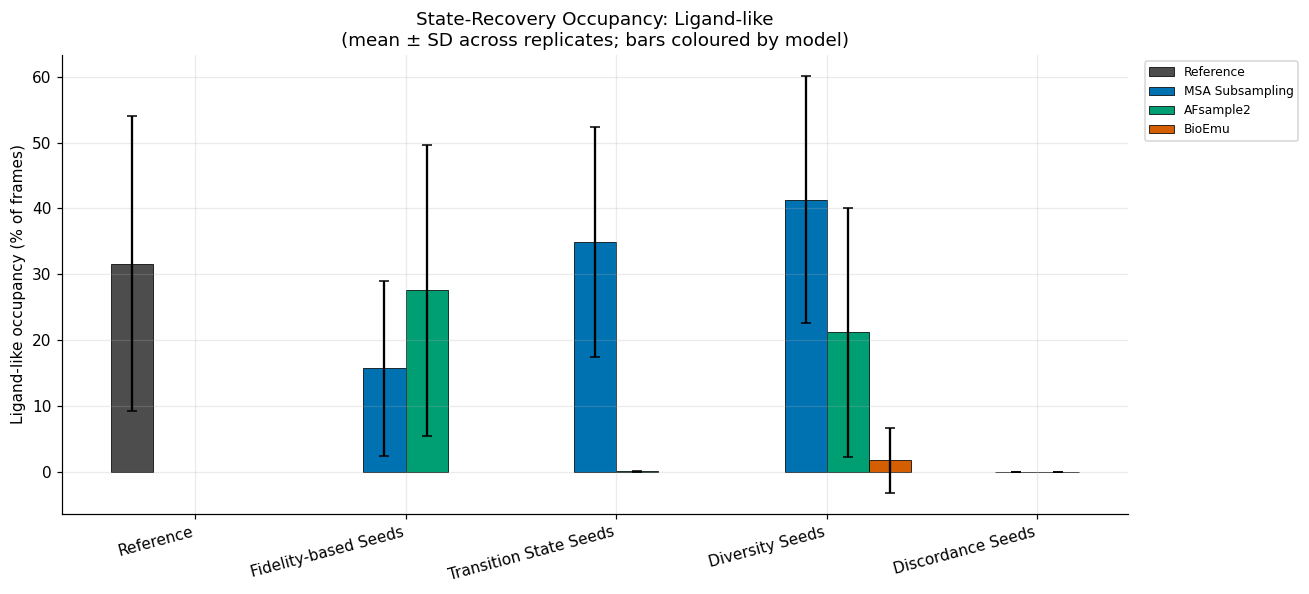

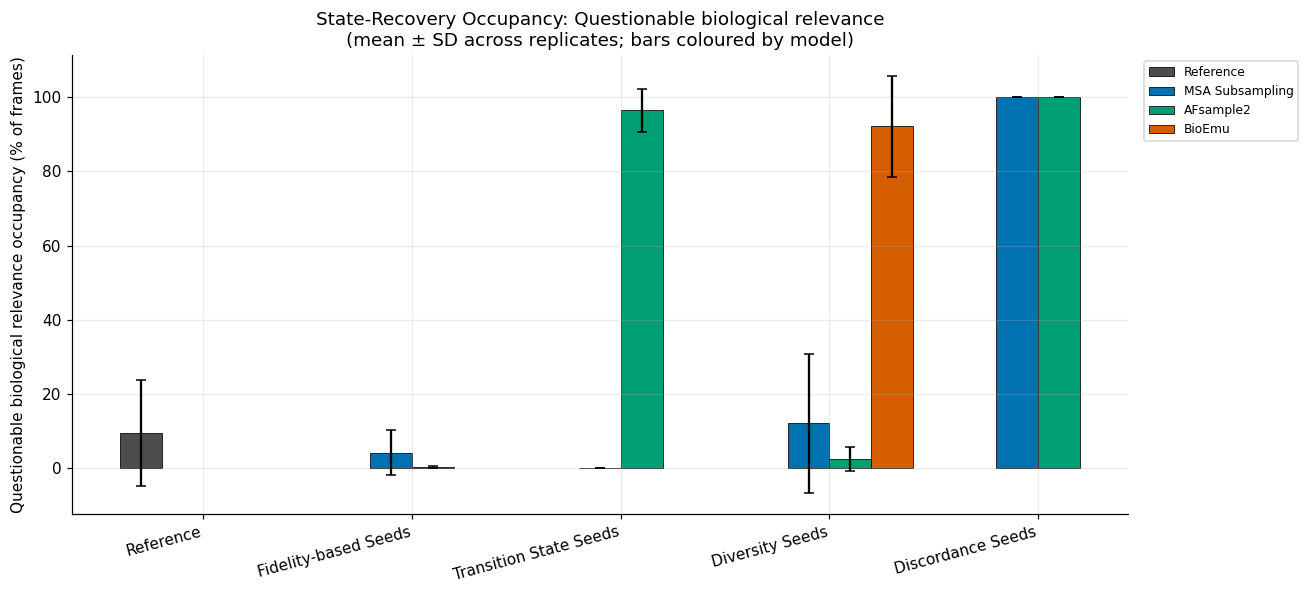

In [26]:
for _state in ["apo", "holo", "ligand", "questionable_relevance"]:
    _sub_state = state_recovery_df[state_recovery_df["state"] == _state]
    fig, ax = plt.subplots(figsize=(12, 5.5))
    _bar_width = 0.8 / len(MODEL_ORDER)
    for _mi, _model in enumerate(MODEL_ORDER):
        _xs, _heights, _errs = [], [], []
        for _gi, _group in enumerate(GROUP_ORDER):
            _sub = _sub_state[(_sub_state["philosophy_group"] == _group) & (_sub_state["model"] == _model)]
            if len(_sub) == 0:
                continue
            _xs.append(_gi + (_mi - (len(MODEL_ORDER) - 1) / 2) * _bar_width)
            _heights.append(_sub["occupancy_pct"].mean())
            _errs.append(_sub["occupancy_pct"].std())
        if _xs:
            ax.bar(_xs, _heights, width=_bar_width, yerr=_errs, capsize=3,
                   color=MODEL_COLORS.get(_model, "#333"), label=_model,
                   edgecolor="black", linewidth=0.5)
    ax.set_xticks(range(len(GROUP_ORDER)))
    ax.set_xticklabels(GROUP_ORDER, rotation=15, ha="right")
    ax.set_ylabel(f"{STATE_RECOVERY_LABELS[_state]} occupancy (% of frames)")
    ax.set_title(f"State-Recovery Occupancy: {STATE_RECOVERY_LABELS[_state]}\n"
                 "(mean ± SD across replicates; bars coloured by model)")
    ax.legend(fontsize=8, loc="upper left", bbox_to_anchor=(1.01, 1.0))
    plt.tight_layout()
    plt.savefig(f"{FIGURES_DIR}/state_recovery_{_state}.png", dpi=150, bbox_inches="tight")
    plt.show()

**Interpretation.** Read each panel as: for a given seed group (x-axis) and model (bar colour), what fraction of that system's frames satisfy the landmark-specific criterion for this state? A fidelity-ligand seed with high ligand-like occupancy and low questionable-relevance occupancy is directly corroborated by this analysis — it was selected as ligand-like and it *stays* ligand-like dynamically. A seed selected on a different criterion (transition-state, diversity, discordance) is not expected to show high occupancy in any single state, since it was not selected to sit in one basin in the first place (Section 3) — for those groups, a high `questionable_relevance` occupancy is the *expected* outcome, not a failure signal, provided it stays consistent with what Sections 4 and 6 already show about that seed's dynamic behaviour.

Even the empirical ceiling for this analysis is incomplete on this timescale: the ligand-bound reference trajectory (`open_1PY2`) does not fully recover its own crystallographic pocket volume within 10 ns, direct dynamic evidence that the cryptic-pocket transition is thermodynamically disfavoured and only rarely, transiently sampled even by dedicated MD on tractable timescales (thesis Section 4.5, citing Oleinikovas et al., 2016; Saleh et al., 2024). Any AI-seeded system's `ligand`-occupancy should therefore be read relative to that reference ceiling, not against a naive 100% expectation.

**Reproducibility.** Within-seed and within-group SD of `occupancy_pct`, same convention used throughout this notebook: flagged where SD exceeds half the mean.

In [27]:
def state_recovery_reproducibility(df, group_cols):
    rows = []
    for keys, g in df.groupby(group_cols):
        keys = keys if isinstance(keys, tuple) else (keys,)
        mean_v = float(g["occupancy_pct"].mean())
        sd_v = float(g["occupancy_pct"].std()) if len(g) > 1 else np.nan
        row = dict(zip(group_cols, keys))
        row.update(occupancy_pct_mean=round(mean_v, 2),
                    occupancy_pct_sd=round(sd_v, 2) if not np.isnan(sd_v) else np.nan,
                    n=len(g))
        rows.append(row)
    out = pd.DataFrame(rows)
    for _, row in out.iterrows():
        if pd.notna(row["occupancy_pct_sd"]) and row["occupancy_pct_sd"] > 0.5 * row["occupancy_pct_mean"]:
            print(f"REPRODUCIBILITY FLAG: {dict(row[group_cols])} SD ({row['occupancy_pct_sd']:.1f}) "
                  f"exceeds half the mean ({row['occupancy_pct_mean']:.1f}) -- not reproducible across replicates.")
    return out


state_recovery_within_seed_df = state_recovery_reproducibility(
    state_recovery_df.assign(model=lambda d: d["system"].map(lambda s: SYSTEM_BY_NAME[s]["model"]),
                              criterion=lambda d: d["system"].map(lambda s: SYSTEM_BY_NAME[s]["criterion"])),
    ["system", "model", "criterion", "state"])
display_table(state_recovery_within_seed_df, caption="Per-system state-recovery reproducibility (occupancy % mean ± SD)")

REPRODUCIBILITY FLAG: {'system': 'ai_seeds_AFsample2_02_fidelity_ligand', 'model': 'AFsample2', 'criterion': 'fidelity_ligand', 'state': 'ligand'} SD (22.1) exceeds half the mean (27.6) -- not reproducible across replicates.
REPRODUCIBILITY FLAG: {'system': 'ai_seeds_AFsample2_02_fidelity_ligand', 'model': 'AFsample2', 'criterion': 'fidelity_ligand', 'state': 'questionable_relevance'} SD (0.3) exceeds half the mean (0.2) -- not reproducible across replicates.
REPRODUCIBILITY FLAG: {'system': 'ai_seeds_AFsample2_03_transition_state', 'model': 'AFsample2', 'criterion': 'transition_state', 'state': 'apo'} SD (5.8) exceeds half the mean (3.5) -- not reproducible across replicates.
REPRODUCIBILITY FLAG: {'system': 'ai_seeds_AFsample2_03_transition_state', 'model': 'AFsample2', 'criterion': 'transition_state', 'state': 'ligand'} SD (0.1) exceeds half the mean (0.1) -- not reproducible across replicates.
REPRODUCIBILITY FLAG: {'system': 'ai_seeds_AFsample2_04_diversity_representative', 'model

system,model,criterion,state,occupancy_pct_mean,occupancy_pct_sd,n
ai_seeds_AFsample2_02_fidelity_ligand,AFsample2,fidelity_ligand,apo,98.50,2.60,3
ai_seeds_AFsample2_02_fidelity_ligand,AFsample2,fidelity_ligand,holo,88.04,10.14,3
ai_seeds_AFsample2_02_fidelity_ligand,AFsample2,fidelity_ligand,ligand,27.57,22.13,3
ai_seeds_AFsample2_02_fidelity_ligand,AFsample2,fidelity_ligand,questionable_relevance,0.17,0.29,3
ai_seeds_AFsample2_03_transition_state,AFsample2,transition_state,apo,3.53,5.77,3
ai_seeds_AFsample2_03_transition_state,AFsample2,transition_state,holo,0.00,0.00,3
ai_seeds_AFsample2_03_transition_state,AFsample2,transition_state,ligand,0.07,0.12,3
ai_seeds_AFsample2_03_transition_state,AFsample2,transition_state,questionable_relevance,96.47,5.77,3
ai_seeds_AFsample2_04_diversity_representative,AFsample2,diversity_representative,apo,95.67,5.41,3
ai_seeds_AFsample2_04_diversity_representative,AFsample2,diversity_representative,holo,80.88,16.72,3


In [28]:
state_recovery_within_group_df = state_recovery_reproducibility(
    state_recovery_df, ["philosophy_group", "state"])
display_table(state_recovery_within_group_df, caption="Per-seed-group state-recovery reproducibility (occupancy % mean ± SD)")

REPRODUCIBILITY FLAG: {'philosophy_group': 'Diversity Seeds', 'state': 'apo'} SD (44.4) exceeds half the mean (37.4) -- not reproducible across replicates.
REPRODUCIBILITY FLAG: {'philosophy_group': 'Diversity Seeds', 'state': 'holo'} SD (33.0) exceeds half the mean (20.8) -- not reproducible across replicates.
REPRODUCIBILITY FLAG: {'philosophy_group': 'Diversity Seeds', 'state': 'ligand'} SD (19.6) exceeds half the mean (13.6) -- not reproducible across replicates.
REPRODUCIBILITY FLAG: {'philosophy_group': 'Diversity Seeds', 'state': 'questionable_relevance'} SD (45.0) exceeds half the mean (58.2) -- not reproducible across replicates.
REPRODUCIBILITY FLAG: {'philosophy_group': 'Fidelity-based Seeds', 'state': 'holo'} SD (34.6) exceeds half the mean (60.9) -- not reproducible across replicates.
REPRODUCIBILITY FLAG: {'philosophy_group': 'Fidelity-based Seeds', 'state': 'ligand'} SD (17.6) exceeds half the mean (21.6) -- not reproducible across replicates.
REPRODUCIBILITY FLAG: {'phi

philosophy_group,state,occupancy_pct_mean,occupancy_pct_sd,n
Discordance Seeds,apo,0.00,0.00,6
Discordance Seeds,holo,0.00,0.00,6
Discordance Seeds,ligand,0.00,0.00,6
Discordance Seeds,questionable_relevance,100.00,0.00,6
Diversity Seeds,apo,37.44,44.42,15
Diversity Seeds,holo,20.75,32.98,15
Diversity Seeds,ligand,13.56,19.58,15
Diversity Seeds,questionable_relevance,58.20,45.03,15
Fidelity-based Seeds,apo,96.72,5.52,6
Fidelity-based Seeds,holo,60.90,34.63,6


Any `REPRODUCIBILITY FLAG` printed above marks a (system, state) or (group, state) cell whose occupancy is highly variable across replicates relative to its own mean — most often either a low-mean cell where even a small absolute SD trips the half-mean threshold, or a genuine case of one replicate behaving qualitatively differently from its siblings. Cross-referencing a flagged cell against Sections 4 and 6 for the same system distinguishes the two: a system already flagged as non-reproducible under RMSD or PCA overlap is expected to be flagged here too, consistent with the architecture-driven pattern established throughout this appendix; a flag appearing *only* here, with no corroborating RMSD/PCA signal, is worth a closer manual look at that specific replicate's trajectory.